In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Read the analysis results
amod_results_dirpath = "data/amod-sim-results/"

amod_scenarios_results = pd.read_csv(os.path.join(amod_results_dirpath, "all_amod_scenario_level_analysis_results.csv"))
amod_scenarios_results.head()

# convert cent to euro
amod_scenarios_results['total_amod_cost'] = amod_scenarios_results['total_amod_cost'] / 100.0

In [3]:
print(amod_scenarios_results.columns)

Index(['fleet_utilization_rate', 'distance_avg_occupancy', 'total_km_driven',
       'average_km_driven', 'total_amod_cost', 'average_amod_cost',
       'total_amod_fix_cost', 'total_amod_variable_cost',
       'total_co2_emissions_g', 'total_external_emission_costs',
       'average_amod_service_rate', 'average_intercity_service_rate',
       'average_intracity_service_rate', 'average_journey_time',
       'average_journey_time_extended', 'average_pt_waiting_time',
       'average_intercity_journey_time',
       'average_intercity_journey_time_extended',
       'average_intracity_journey_time',
       'average_intracity_journey_time_extended', 'random_seed', 'fleet_size',
       'demand_size', 'intra_ratio', 'broker_type',
       'op_max_detour_time_factor', 'op_max_wait_time', 'train_headway',
       'scenario_name'],
      dtype='object')


# Variables

In [4]:
# Train Headway (min)
train_headway_list = [10, 20, 30]

# MoD Fleet Size
mod_fleet_size_list = [30, 50, 70, 90, 110, 130, 150]

# MaaS Platform Communication Strategy
maas_communication_strategy_list = ['default', 'TPCS']

# Random Seed
random_seed_list = [3, 6, 9]

# MoD Waiting Time Threshold (s)
mod_waiting_time_threshold_list = [300, 600, 900]
# MoD Detour Time Threshold (%)
mod_detour_time_threshold_list = [30, 60, 90]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

name_dict = {
    'random_seed': "Random Seed", 
    'fleet_size': "Fleet Size",
    'demand_size': "Demand Size",
    'intra_ratio': "Intra Demand Ratio",
    'op_max_detour_time_factor': "Max Detour Time Factor",
    'op_max_wait_time': "Max Wait Time",
    'train_headway': "Train Headway",
    'average_journey_time': "Average Journey Time",
    'average_intercity_journey_time': "Average Intercity Journey Time",
    'average_intracity_journey_time': "Average Intracity Journey Time",
    'average_journey_time_extended': "Average Journey Time (Extended)",
    'average_intercity_journey_time_extended': "Average Intercity Journey Time (Extended)",
    'average_intracity_journey_time_extended': "Average Intracity Journey Time (Extended)",
    'average_amod_service_rate': "Average AMoD Service Rate",
    'total_amod_cost': "Total AMoD Cost",
    'broker_type': "MaaS Communication Strategy",
    'fleet_utilization_rate': "Fleet Utilization Rate",
}

# Filter

In [5]:
# Remove demand_size = 100 and 200
amod_scenarios_results = amod_scenarios_results[~amod_scenarios_results['demand_size'].isin([100, 200])]

# # Remove (demand size, fleet size) combinations: 
# # - (300, 90), (300, 110), (300, 130), (300, 150)
# # - (400, 110), (400, 130), (400, 150)
# # - (500, 150)
# amod_scenarios_results = amod_scenarios_results[~(
#     ((amod_scenarios_results['demand_size'] == 300) & (amod_scenarios_results['fleet_size'].isin([90, 110, 130, 150]))) |
#     ((amod_scenarios_results['demand_size'] == 400) & (amod_scenarios_results['fleet_size'].isin([110, 130, 150]))) |
#     ((amod_scenarios_results['demand_size'] == 500) & (amod_scenarios_results['fleet_size'] == 150))
# )]

# Interaction Analysis

In [6]:
# variable_name_list = ['random_seed', 'fleet_size', 'demand_size', 'intra_ratio', 'op_max_detour_time_factor', 'op_max_wait_time', 'headway']

# maas_communication_strategy_list = ['default', 'TPCS']

# kpi_list = ['average_journey_time']

# for variable_name in variable_name_list:
#     for kpi in kpi_list:
#         print(f"\nAnalyzing {kpi} by {variable_name}...")
        
#         # Draw interation plots
#         sns.set_style("whitegrid")

#         sns.lineplot(
#             data=amod_scenarios_results,
#             x=variable_name,
#             y=kpi,
#             hue='broker_type',
#             style='broker_type',
#             markers=True,
#             dashes=False,
#             errorbar=('ci', 95)
#         )
        
#         plt.title(f'broker_type vs {variable_name}', fontsize=16)
#         plt.xlabel(f'{variable_name}', fontsize=12)
#         plt.ylabel(f'{kpi}', fontsize=12)
#         plt.legend(title='Strategy')
#         plt.grid(True, which='both', linestyle='--', linewidth=0.5)
#         plt.show()

In [7]:
variable_name_list = ['random_seed', 'fleet_size', 'demand_size', 'intra_ratio', 'op_max_detour_time_factor', 'op_max_wait_time', 'train_headway']

In [8]:
def draw_interaction_plots(
    kpi_column,
    y_axis_limit,
    errorbar=('ci', 95),
    strategy_column='broker_type', 
    variable_name_list=variable_name_list, 
    name_dict=name_dict,
    data=amod_scenarios_results
):

    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    flat_axes = axes.flatten()

    for i, variable_name in enumerate(variable_name_list):
        if i == 6:
            i = 7 # Move to position 7 for 'headway'
        ax = flat_axes[i]
        
        sns.set_style("whitegrid")

        sns.lineplot(
            data=data,
            x=variable_name,
            y=kpi_column,
            hue=strategy_column,
            style=strategy_column, 
            markers=True,
            dashes=False,
            errorbar=errorbar,
            ax=ax,
            legend='auto'
        )

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()
        
        # ax.set_title(f'{name_dict.get(variable_name, variable_name)}', fontsize=14)
        ax.set_xlabel(f'{name_dict.get(variable_name, variable_name)}', fontsize=16)
        ax.set_ylabel(f'{name_dict.get(kpi_column, kpi_column)}', fontsize=16)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        ax.set_ylim(y_axis_limit)
        x_ticks_to_show = sorted(data[variable_name].unique())
        ax.set_xticks(x_ticks_to_show)

        ax.tick_params(labelsize=16)

    flat_axes[6].set_visible(False)
    flat_axes[8].set_visible(False)

    legend_ax = flat_axes[8]
        
    fig.legend(
        handles, 
        labels, 
        title='Strategy', 
        loc='center right', 
        bbox_to_anchor=legend_ax.get_position(),
        ncol=1,
        fontsize=16
    )
        

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

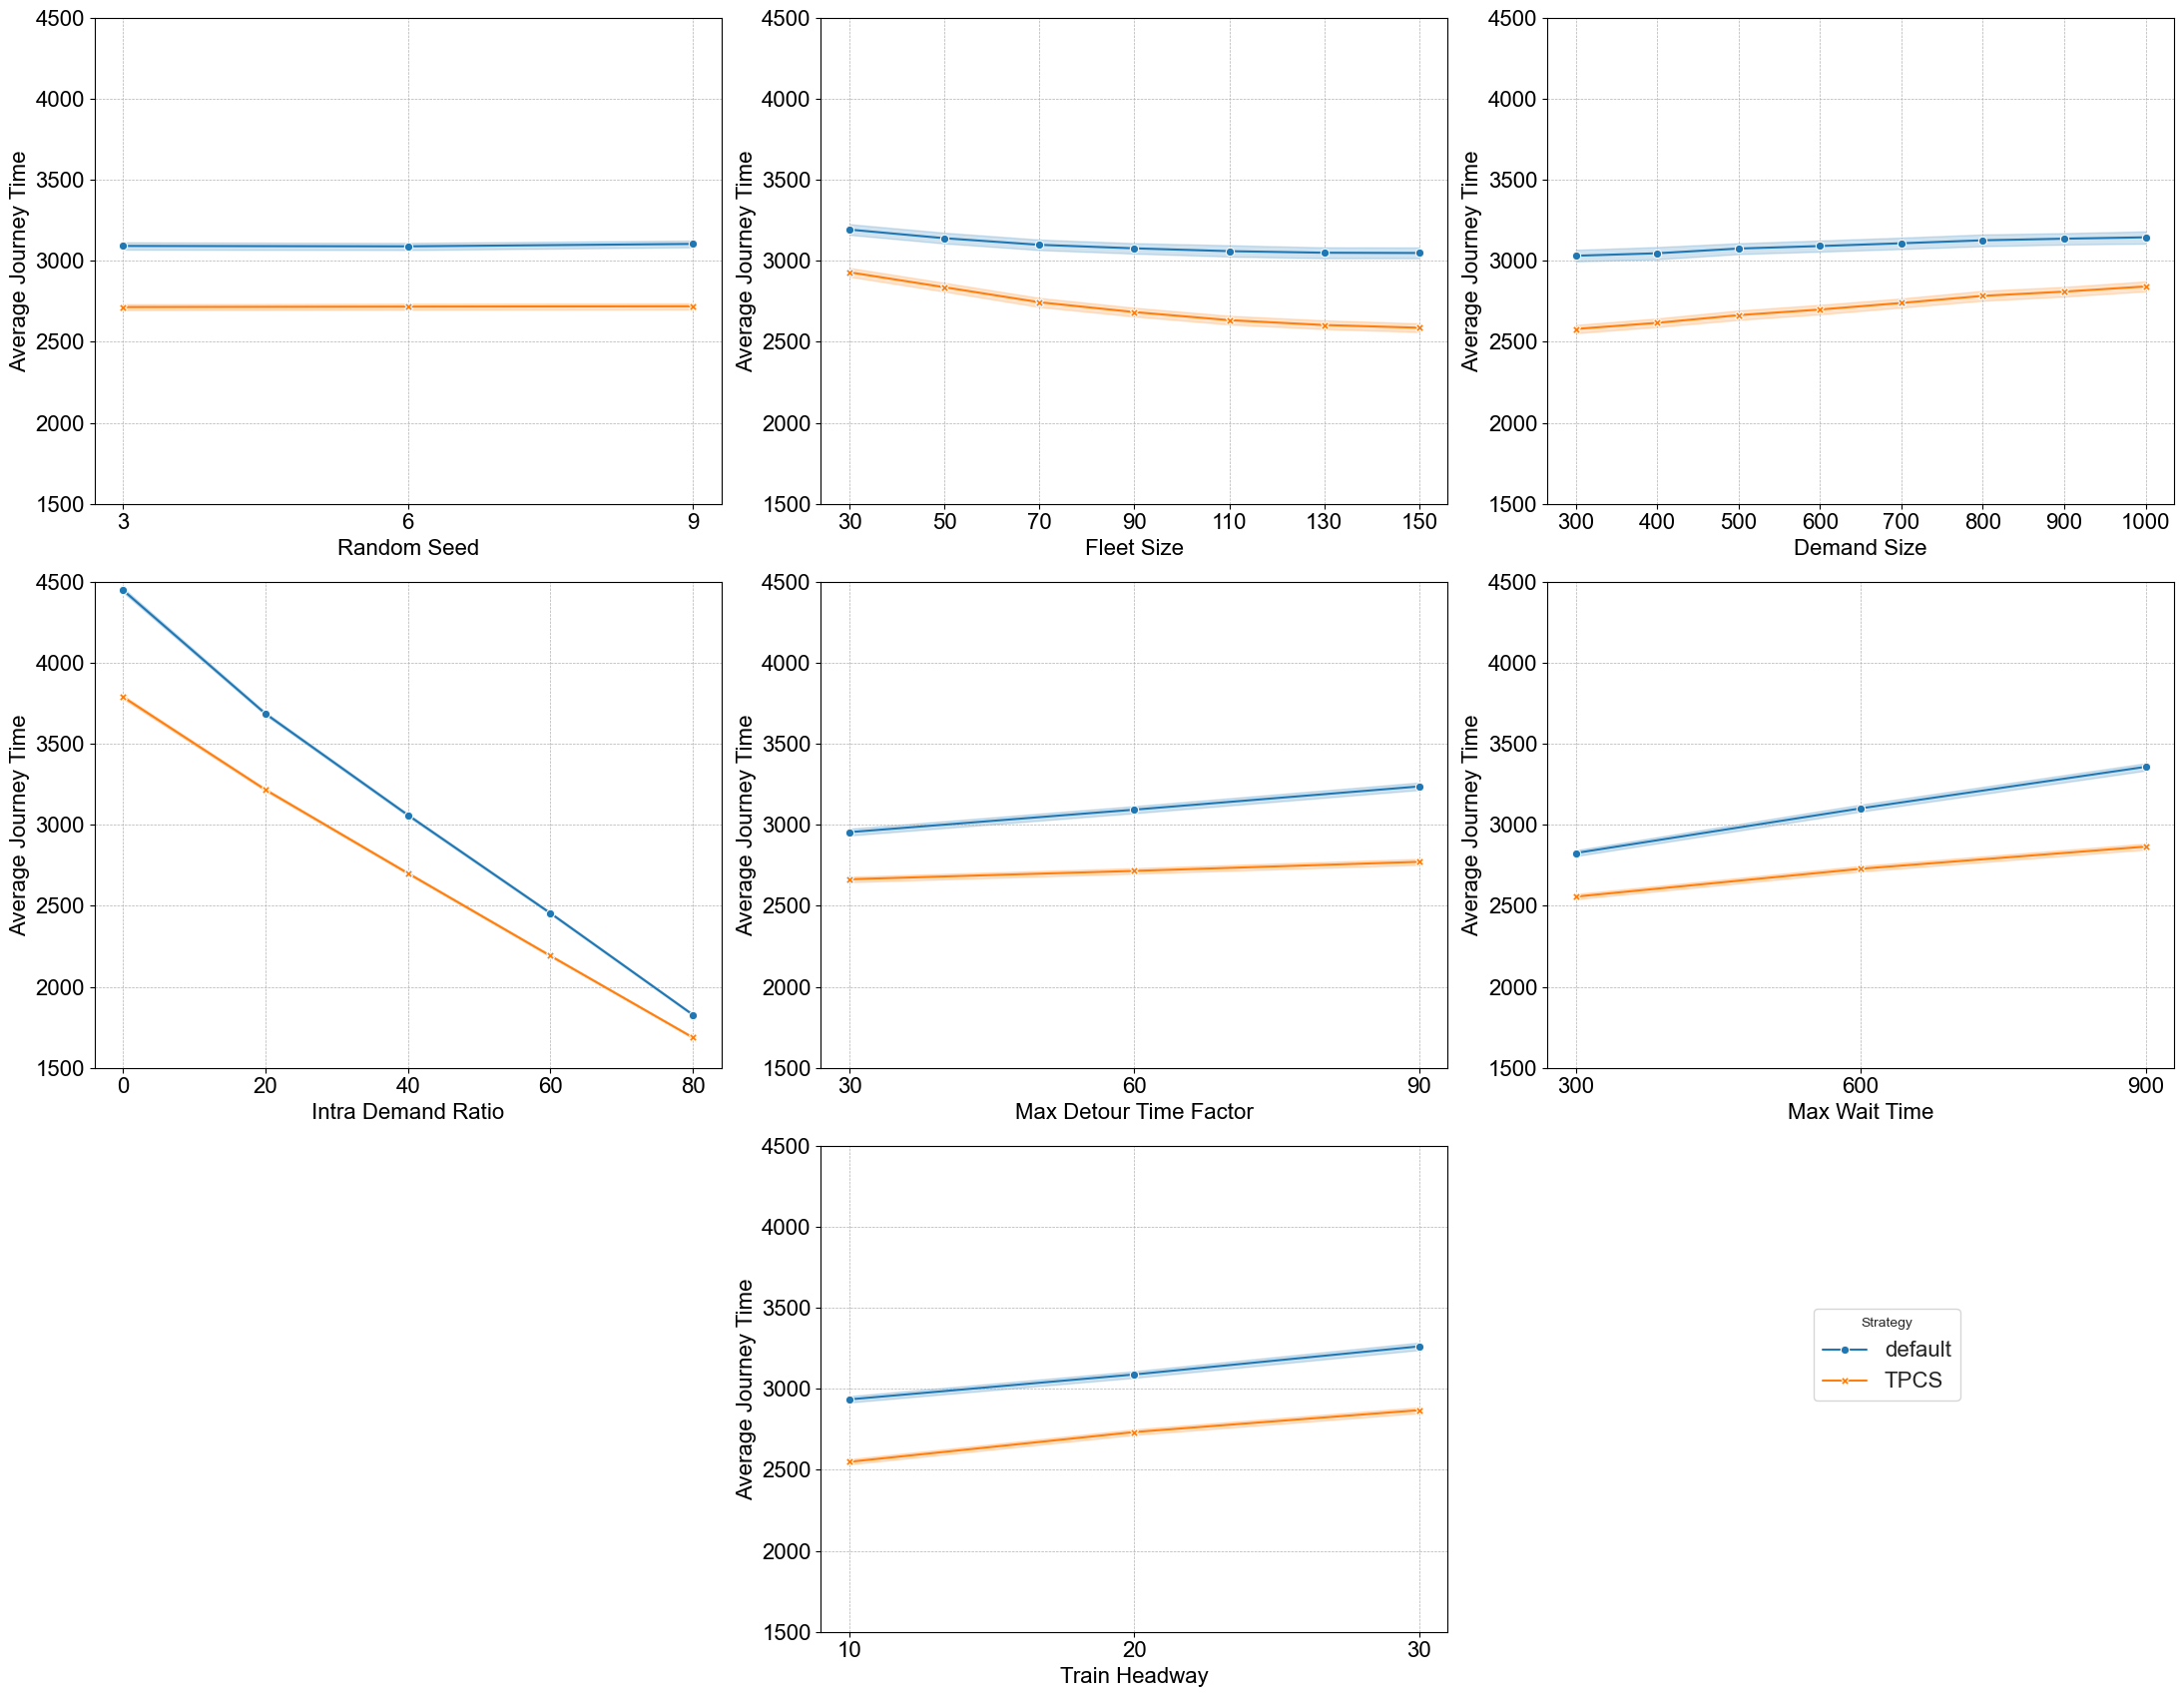

In [9]:
draw_interaction_plots(kpi_column='average_journey_time', y_axis_limit=(1500, 4500))

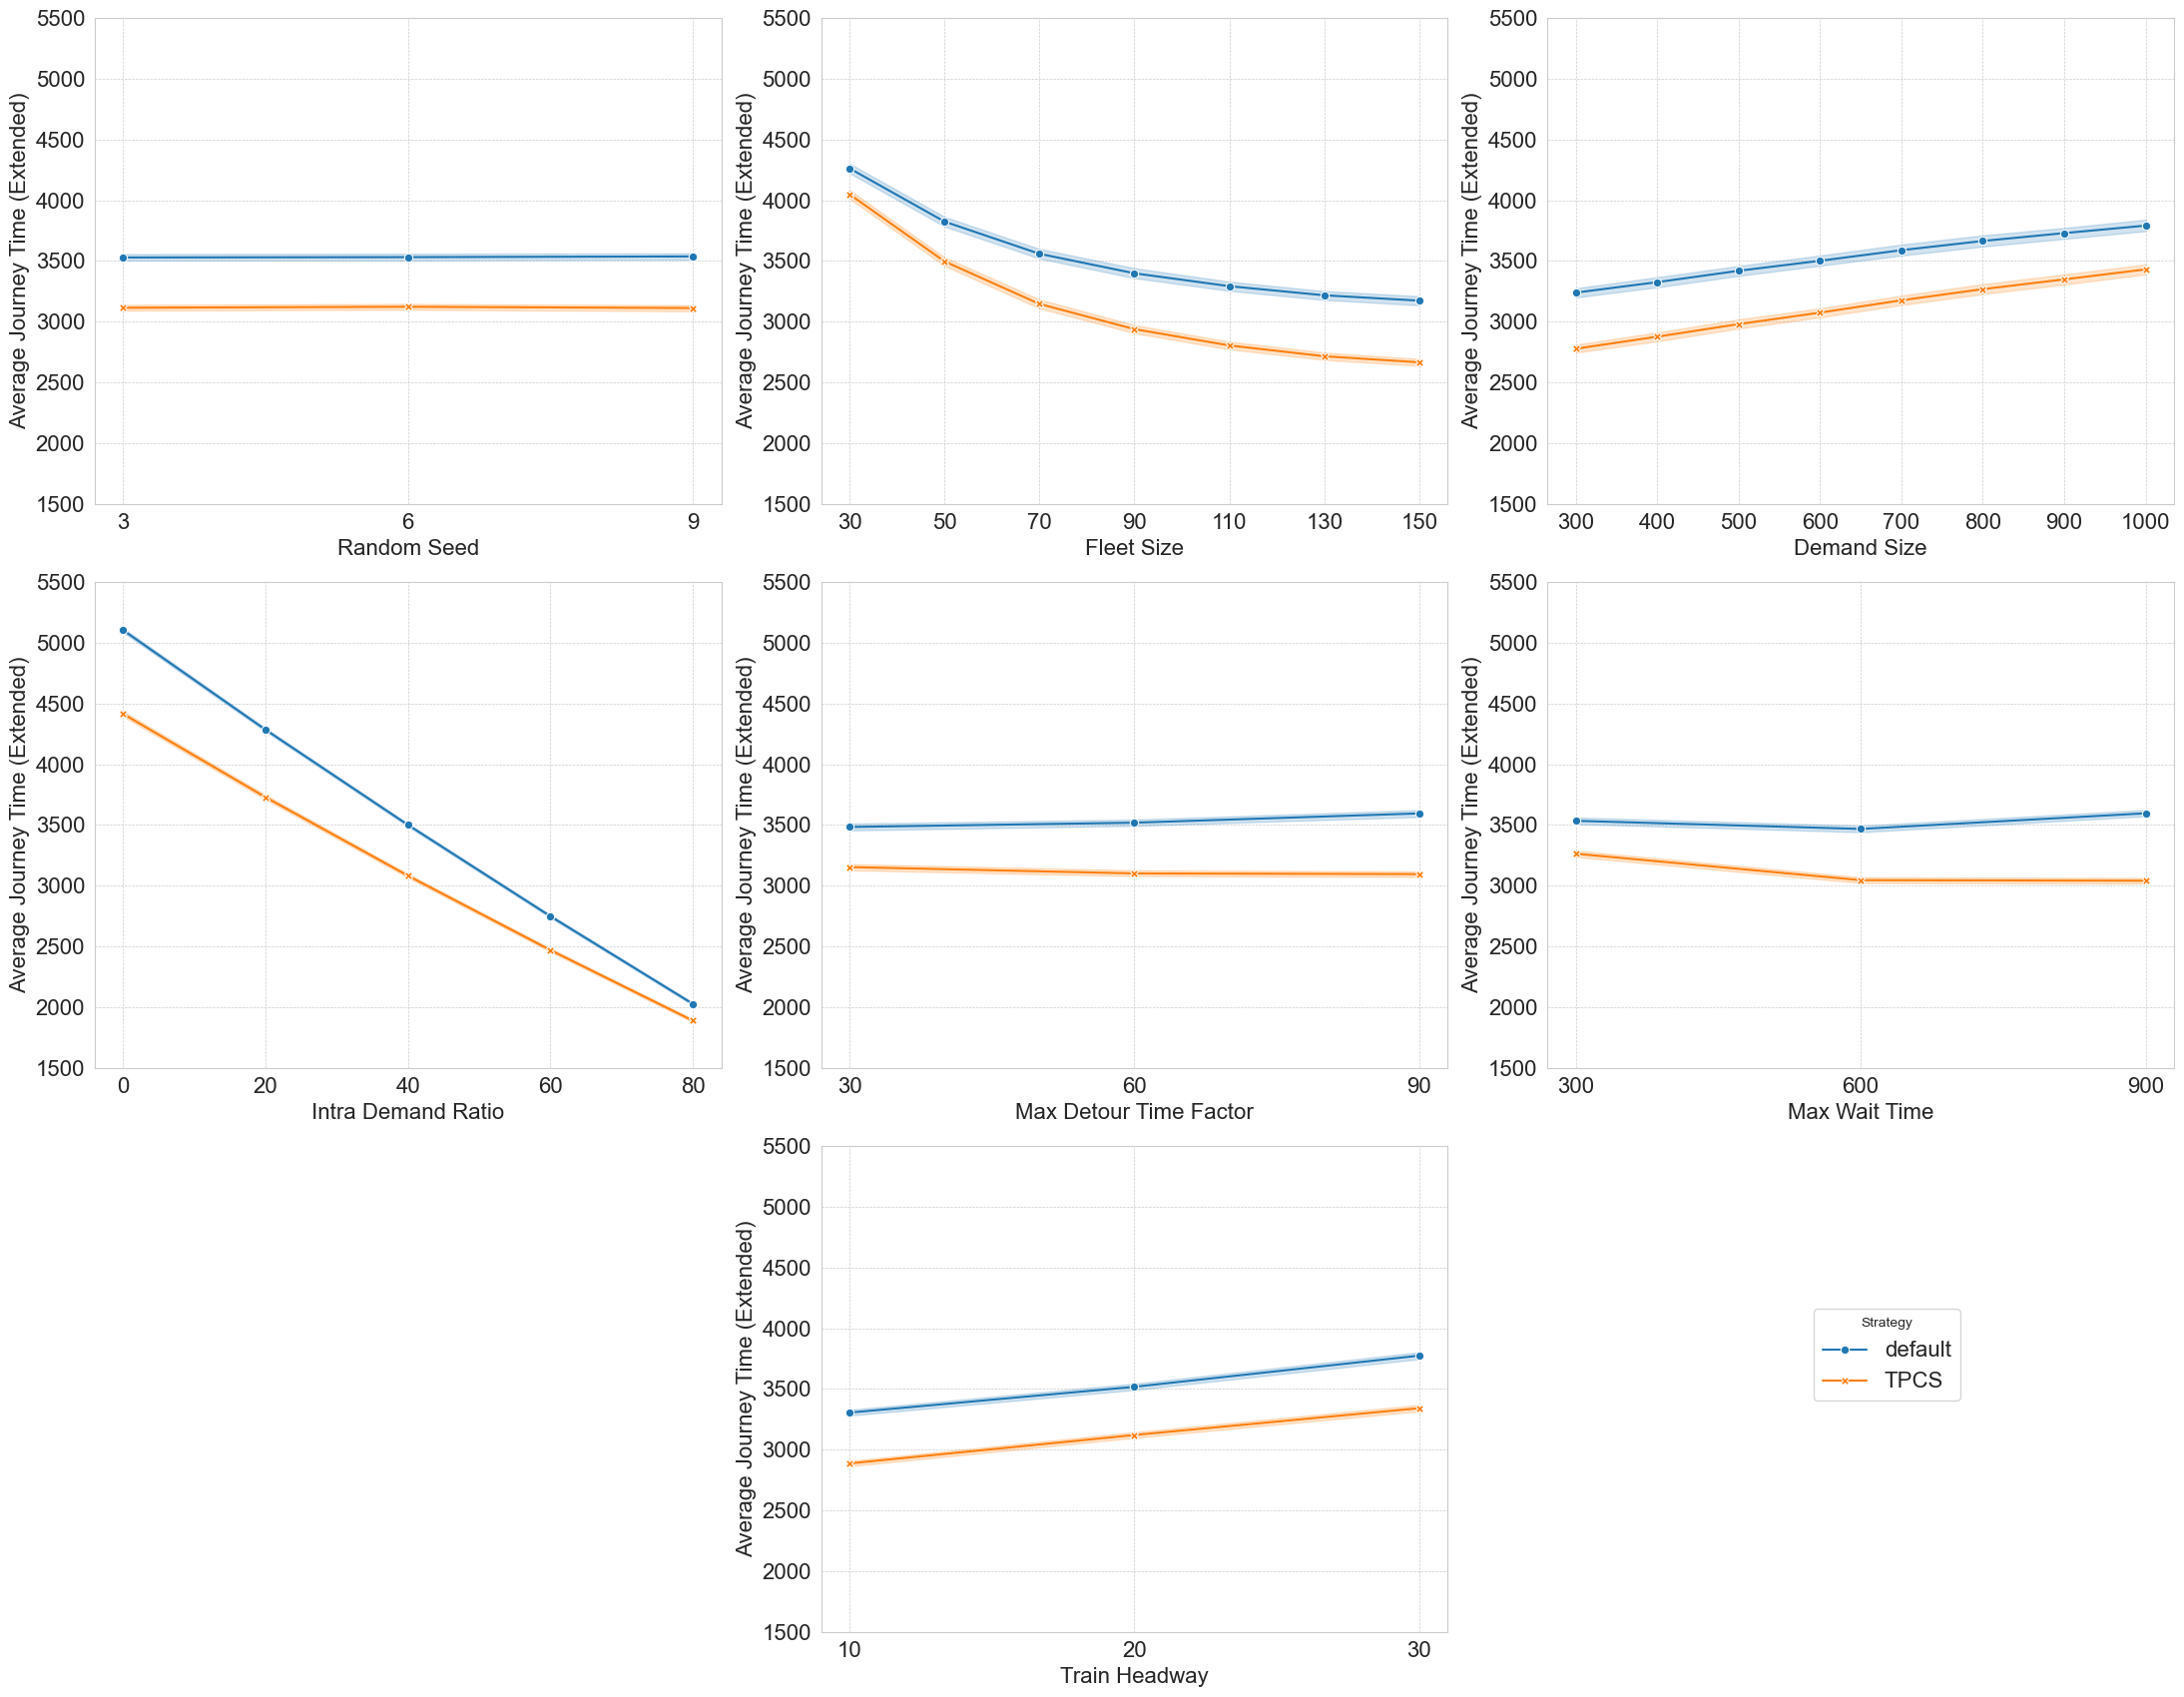

In [10]:
draw_interaction_plots(kpi_column='average_journey_time_extended', y_axis_limit=(1500, 5500))

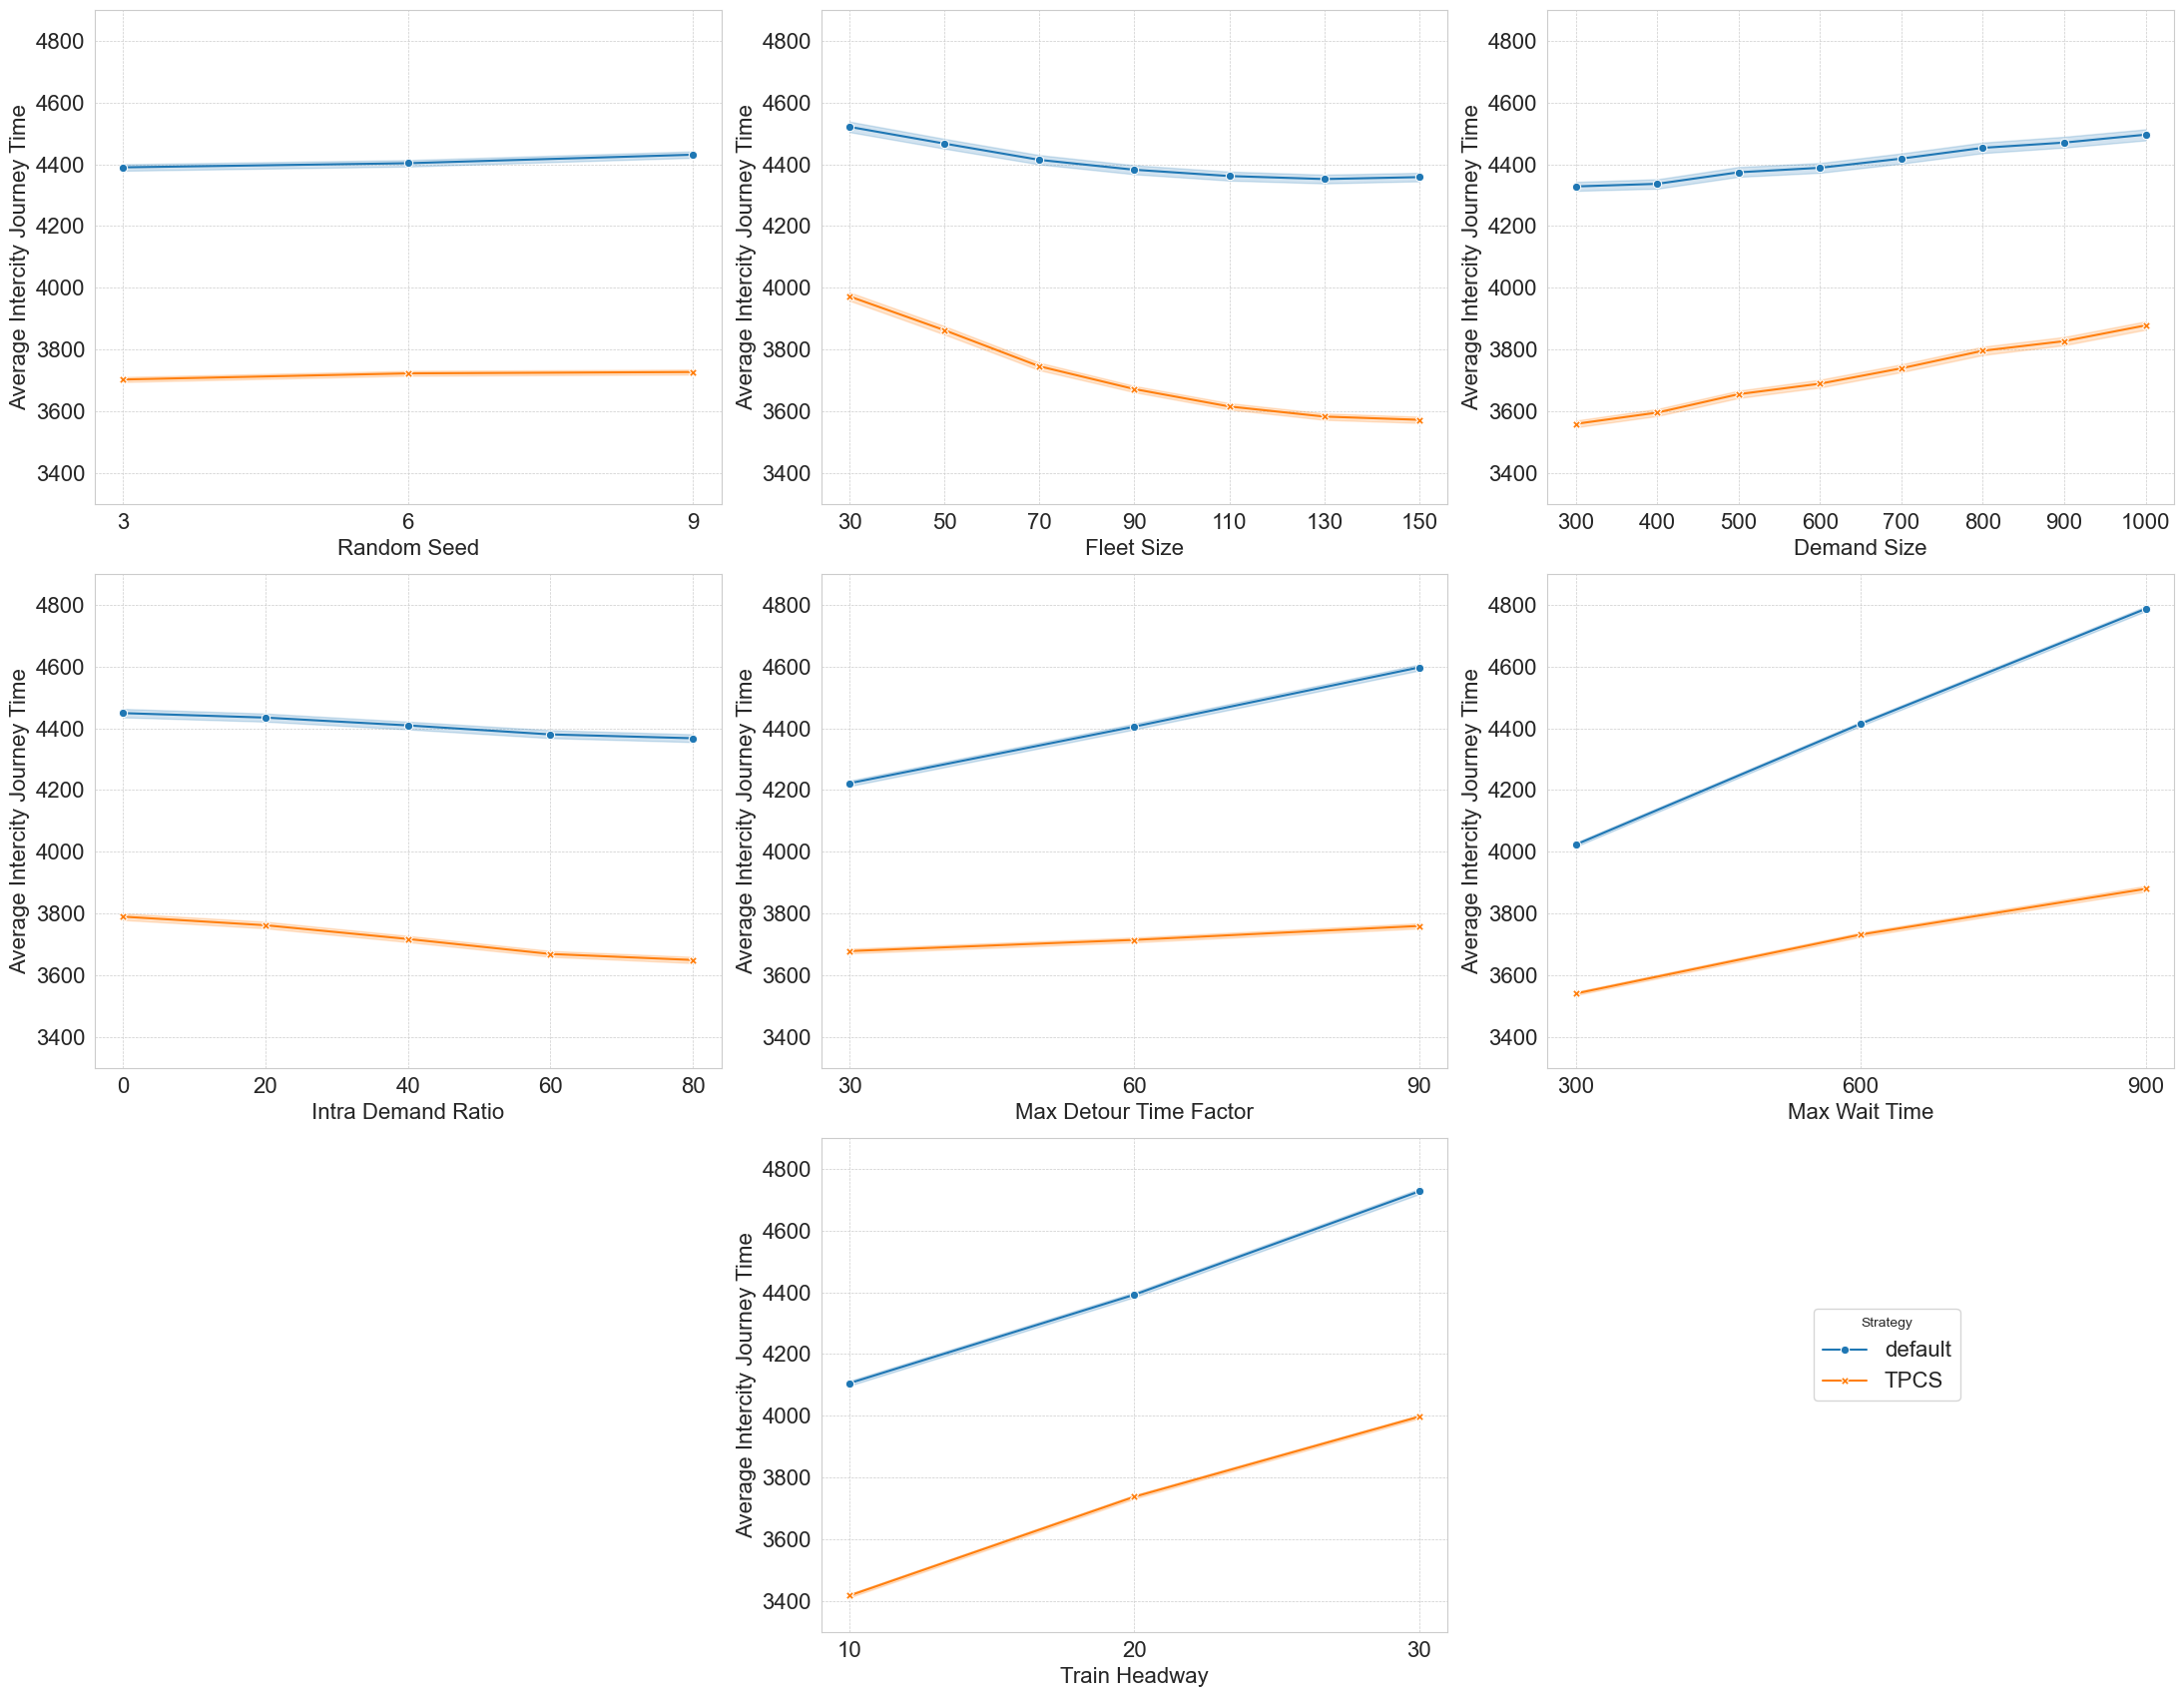

In [11]:
draw_interaction_plots(kpi_column='average_intercity_journey_time', y_axis_limit=(3300, 4900))

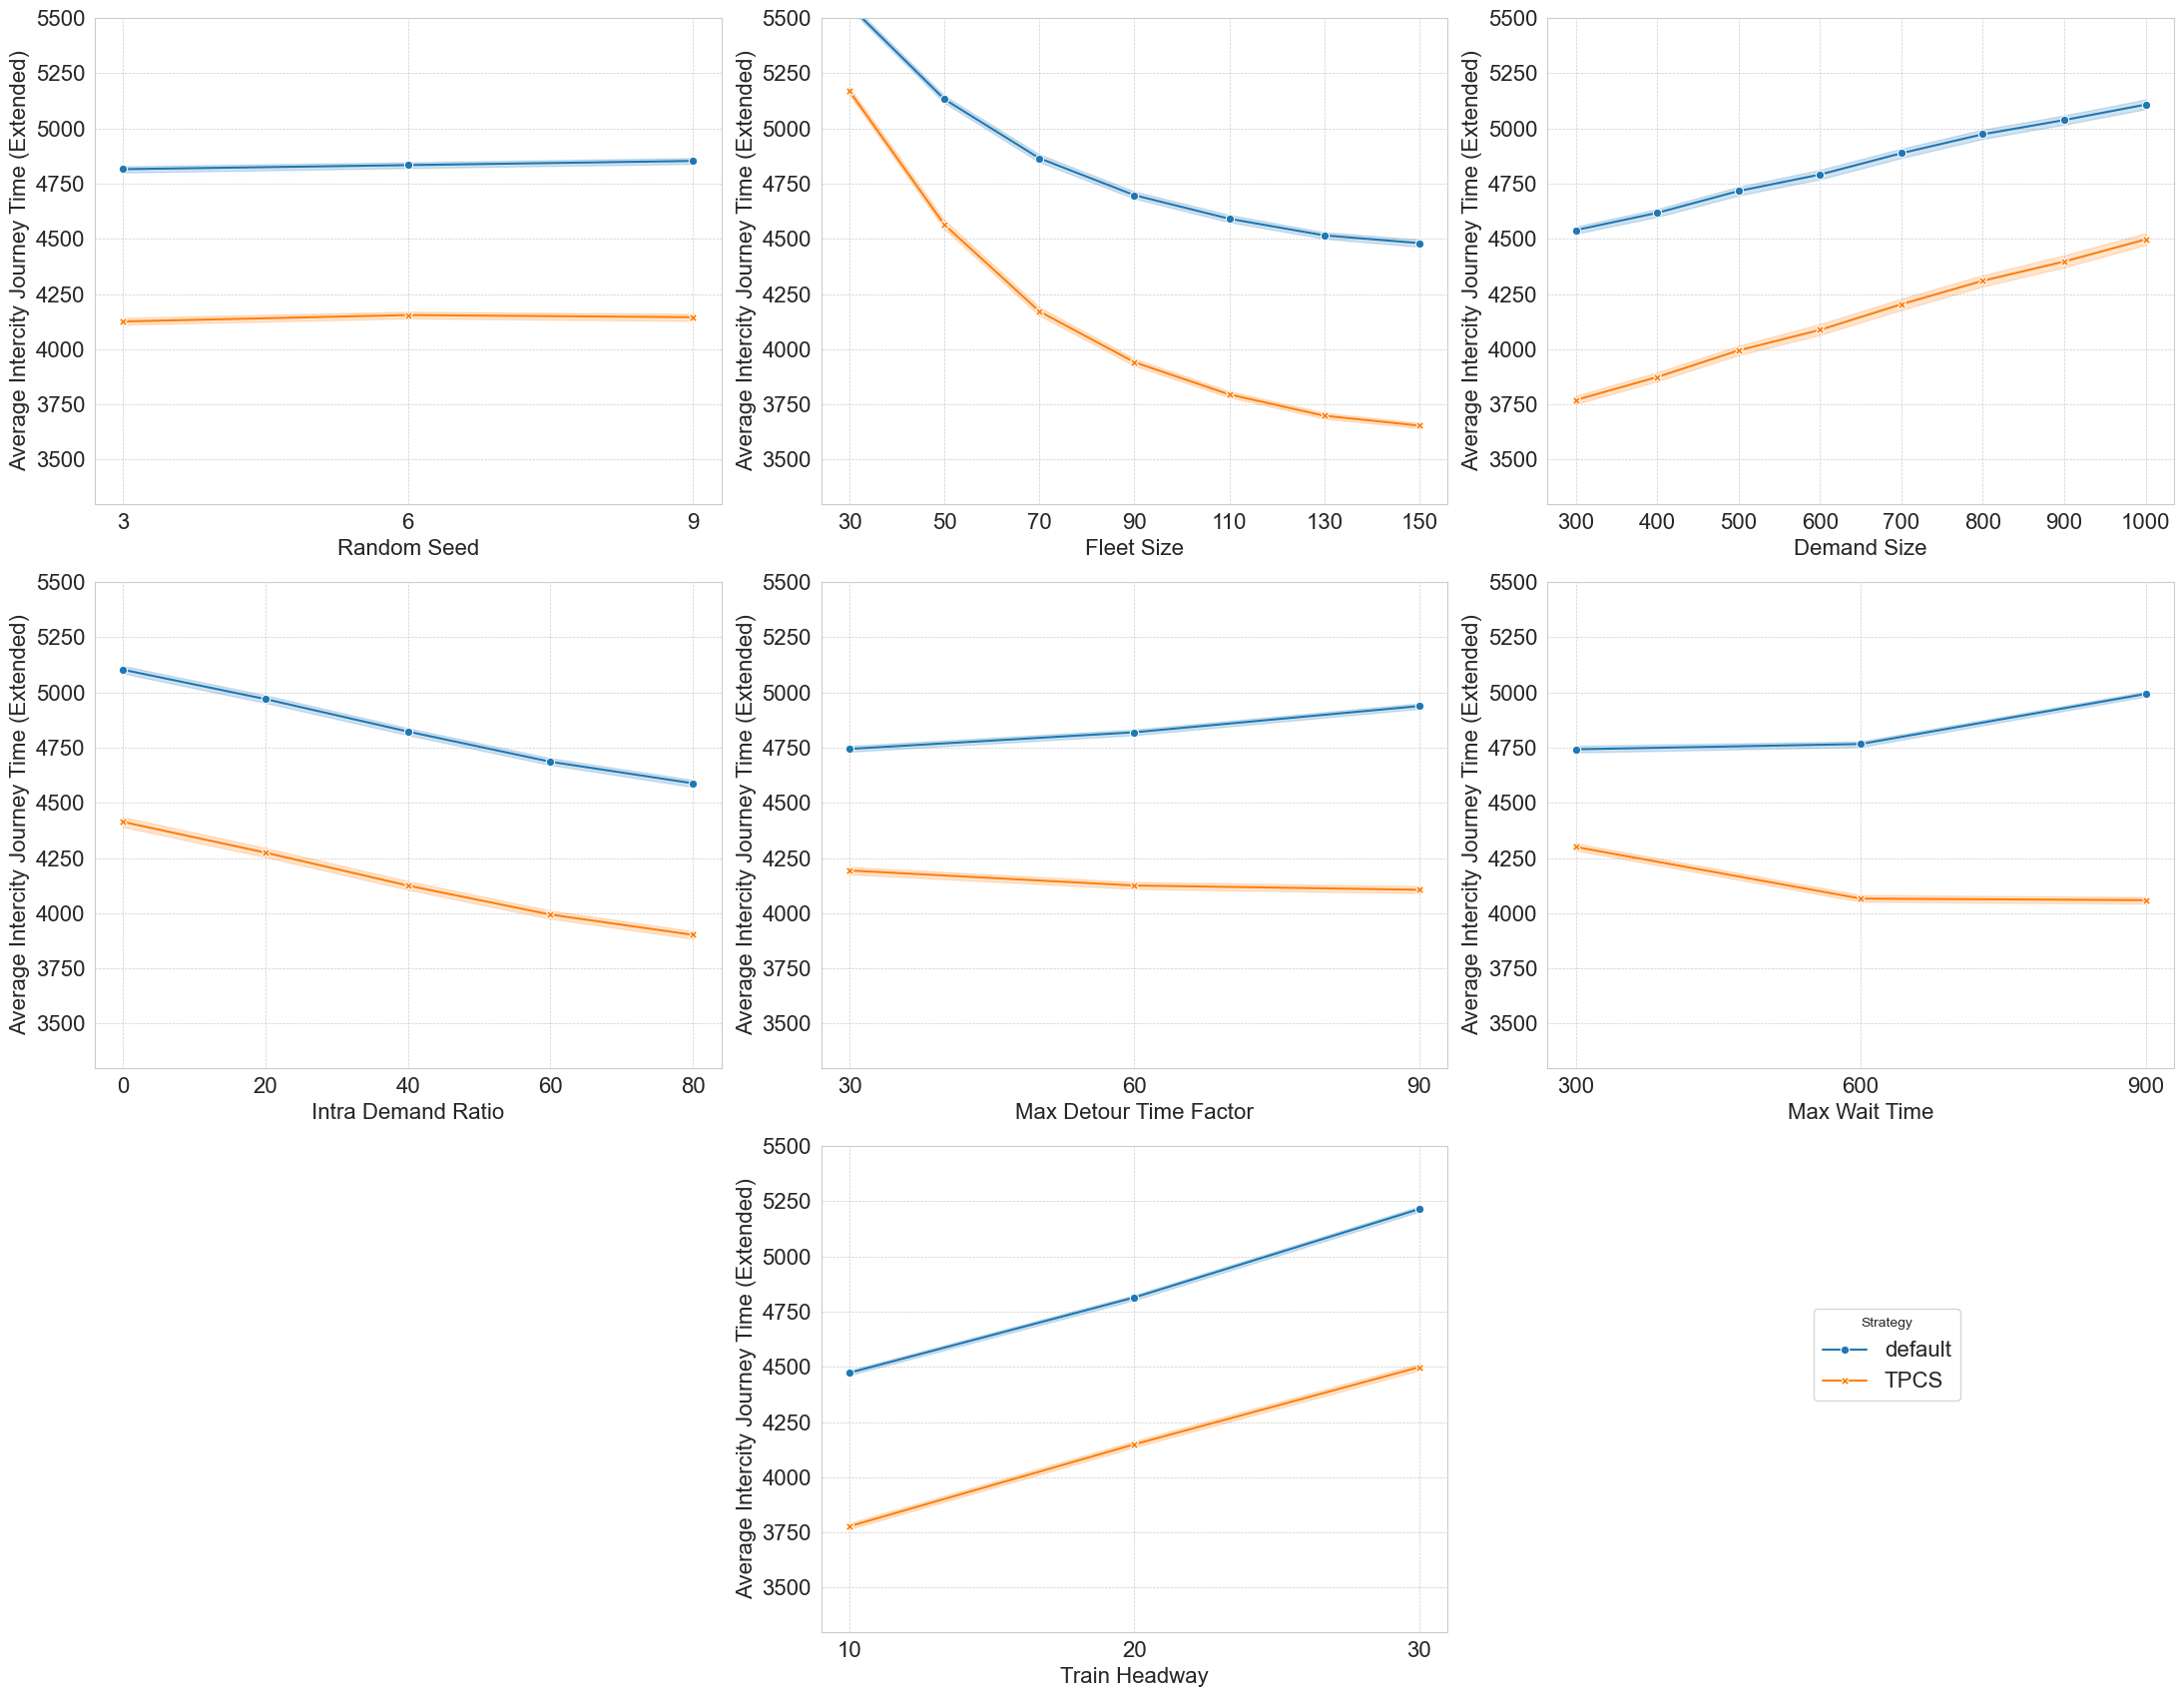

In [12]:
draw_interaction_plots(kpi_column='average_intercity_journey_time_extended', y_axis_limit=(3300, 5500))

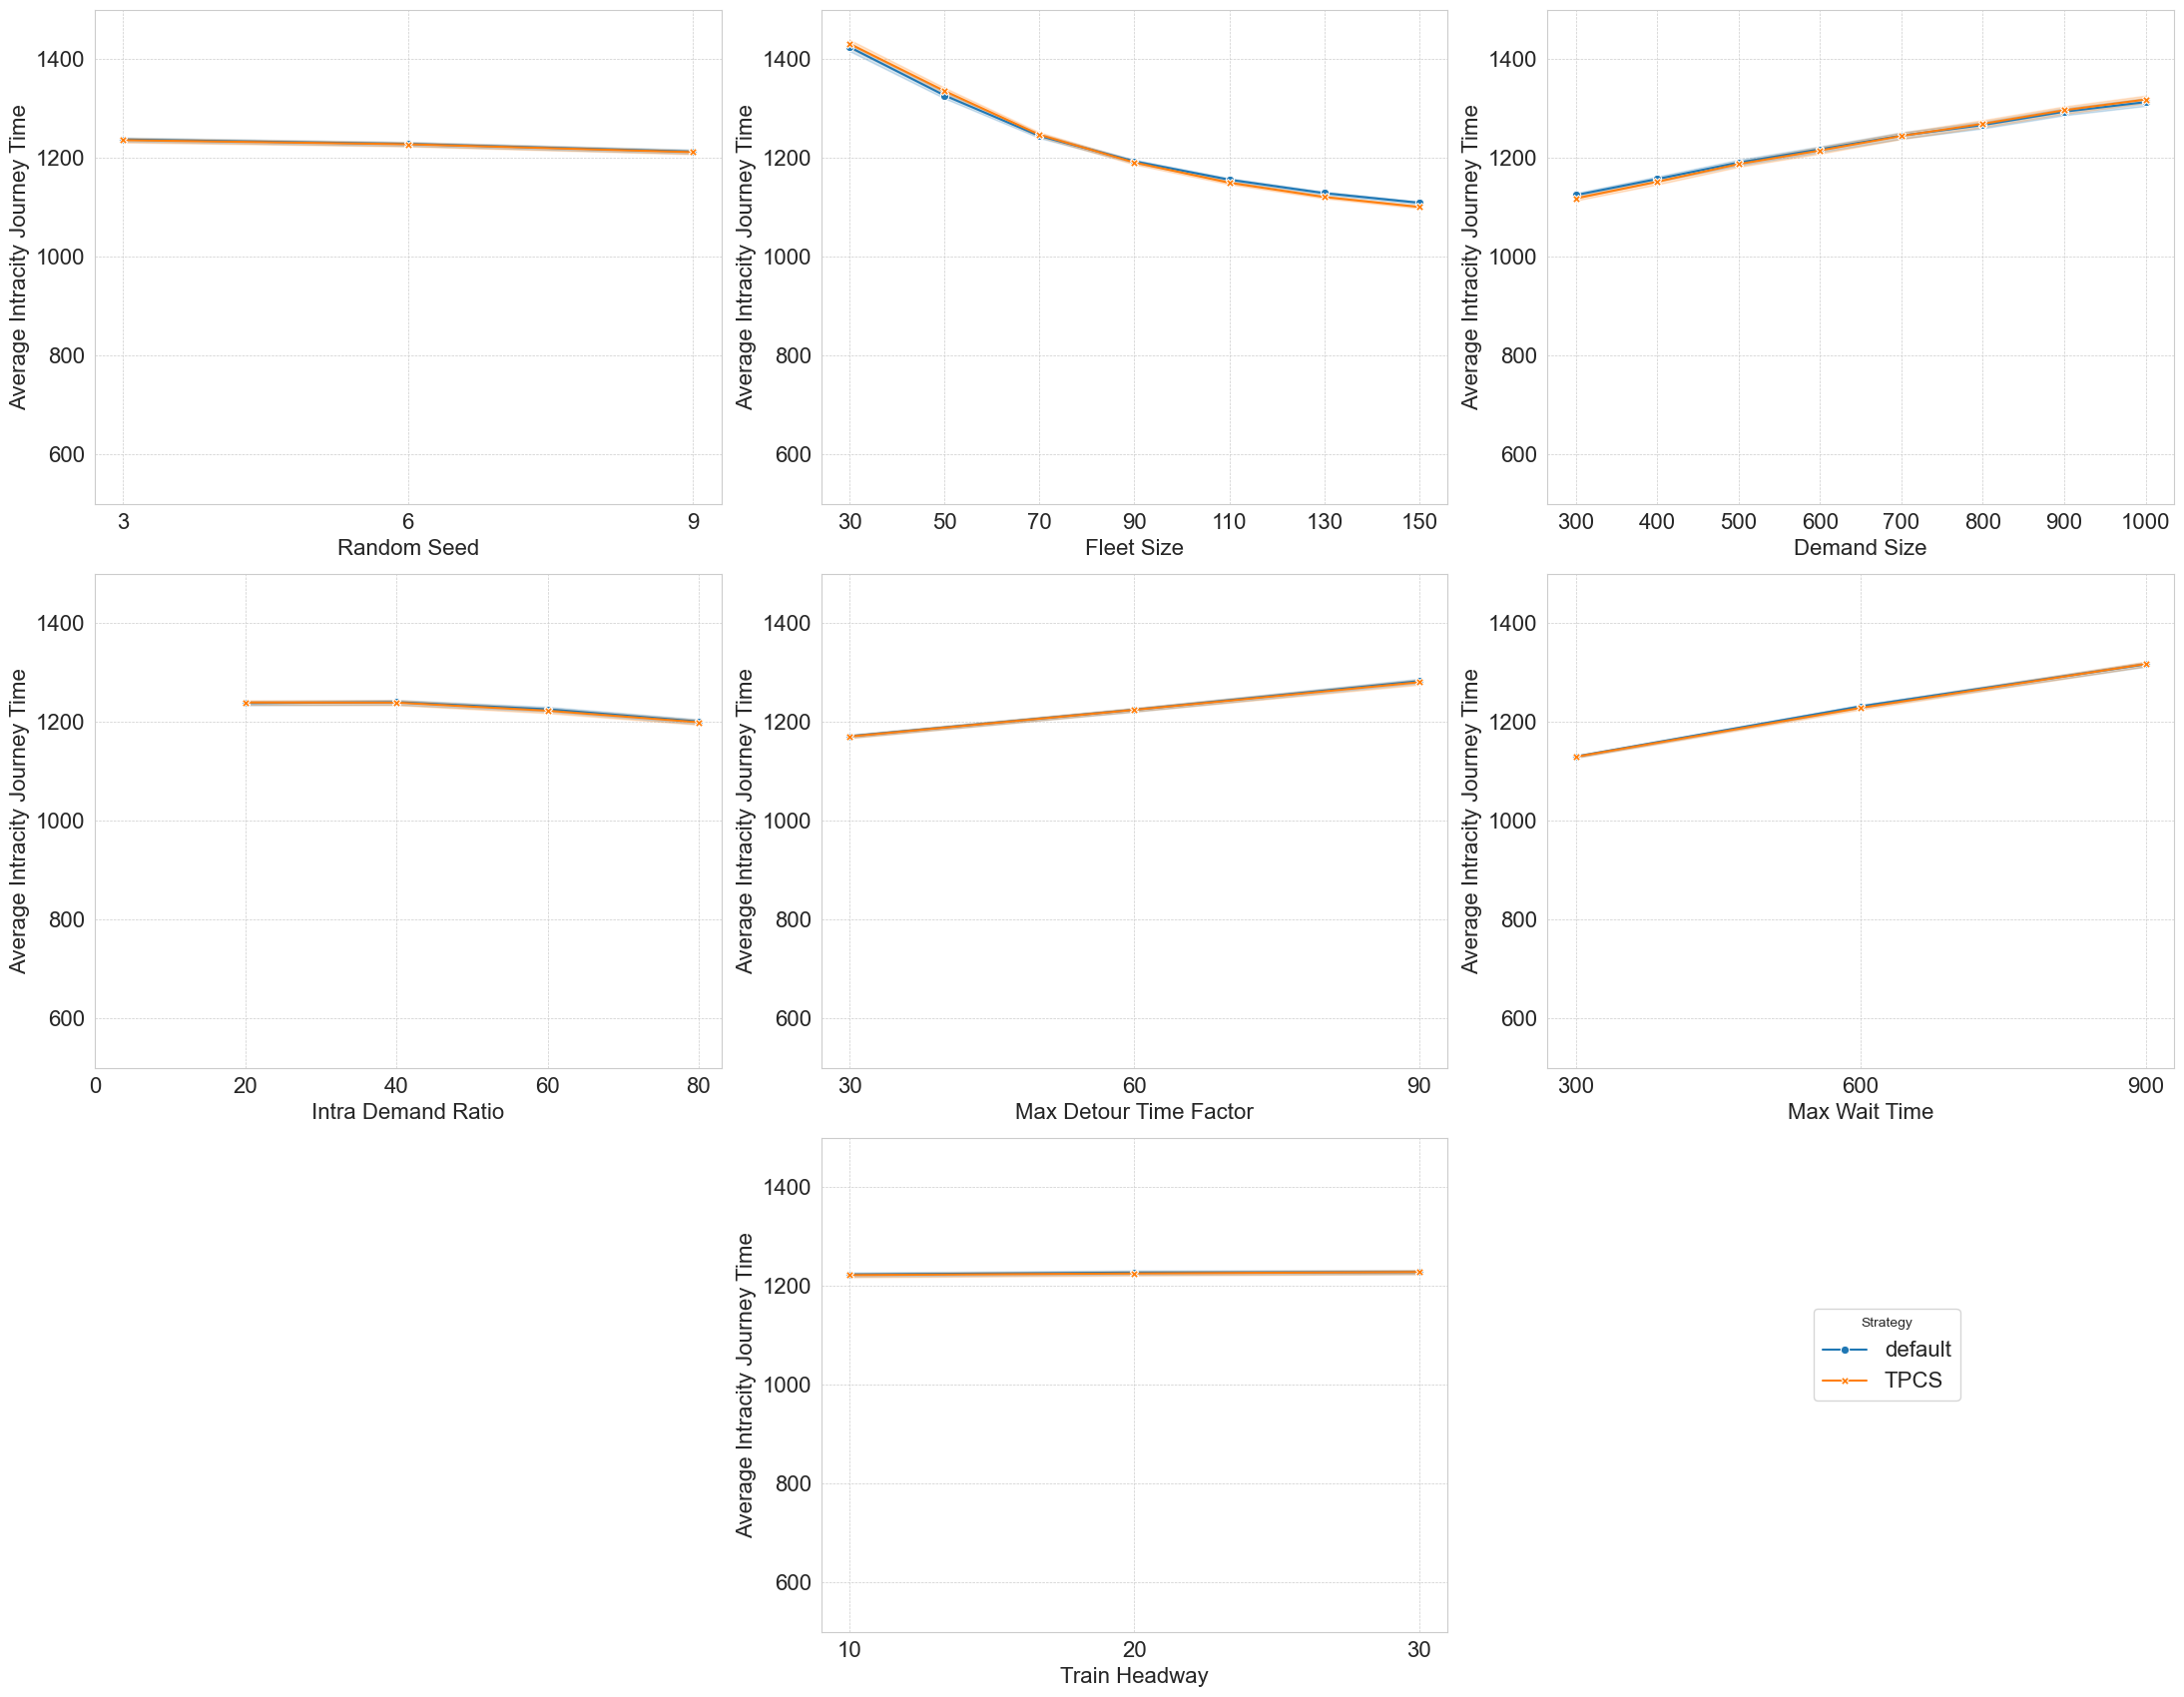

In [13]:
draw_interaction_plots(kpi_column='average_intracity_journey_time', y_axis_limit=(500, 1500))

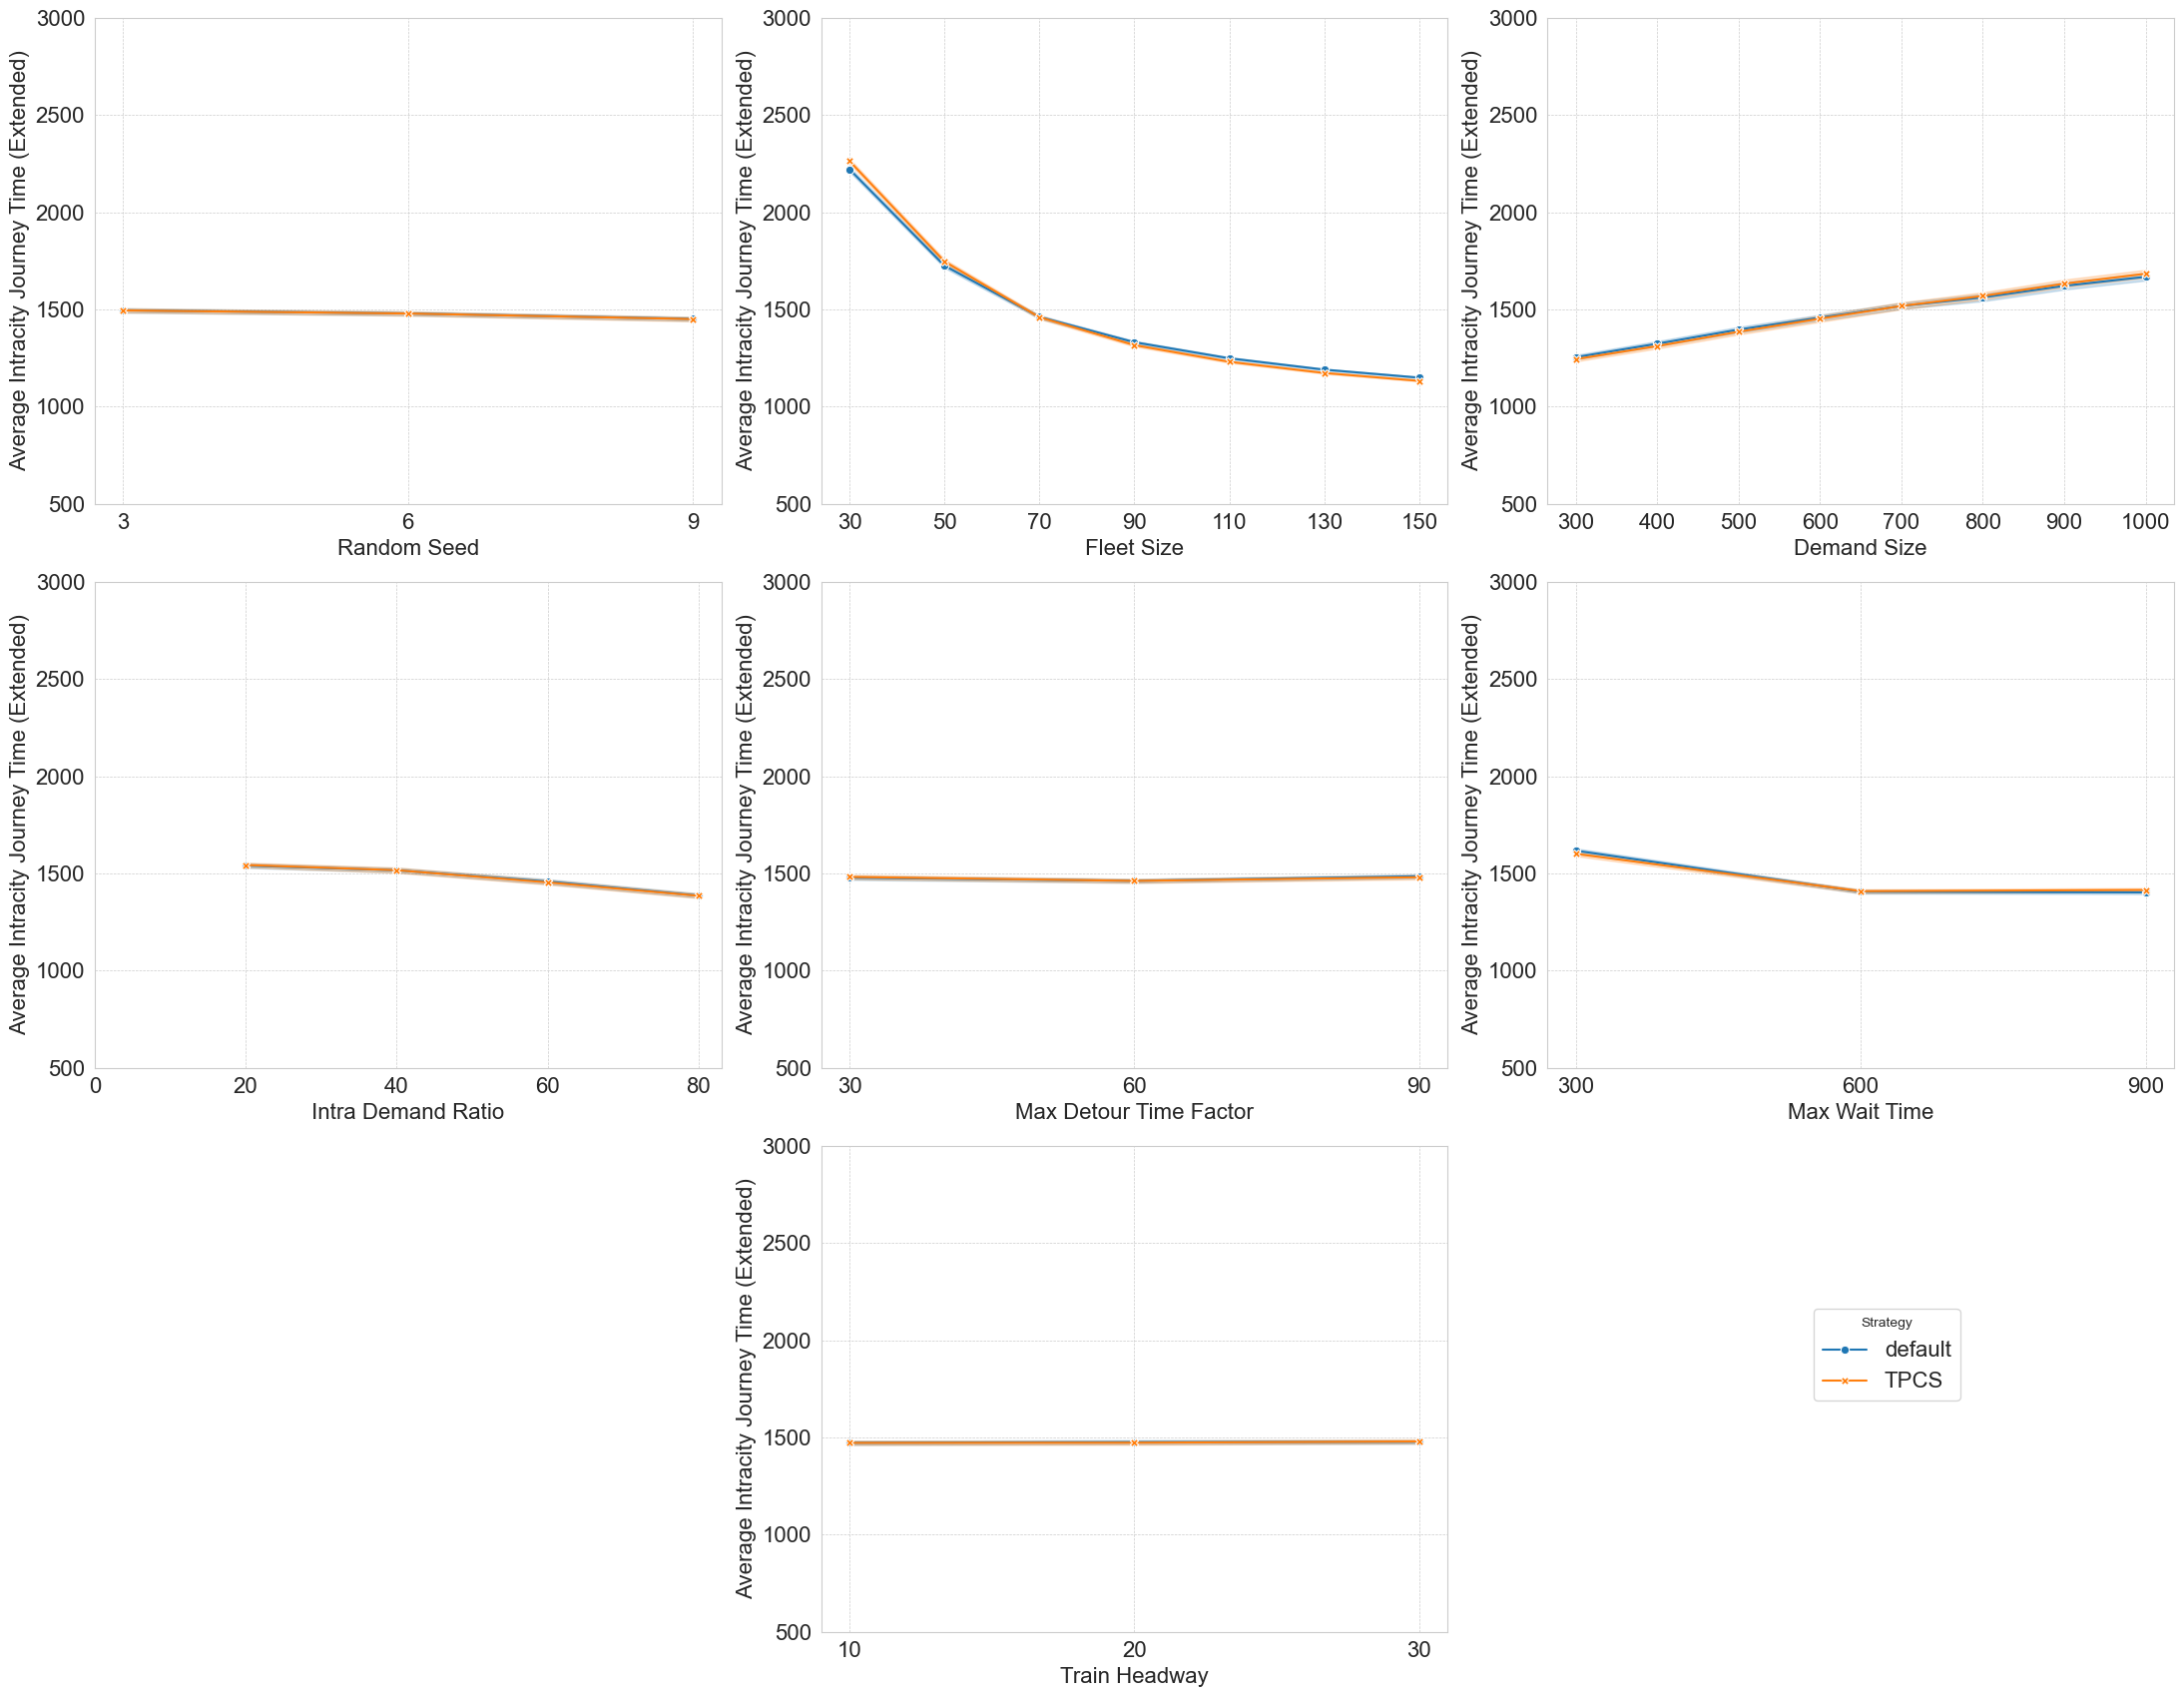

In [14]:
draw_interaction_plots(kpi_column='average_intracity_journey_time_extended', y_axis_limit=(500, 3000))

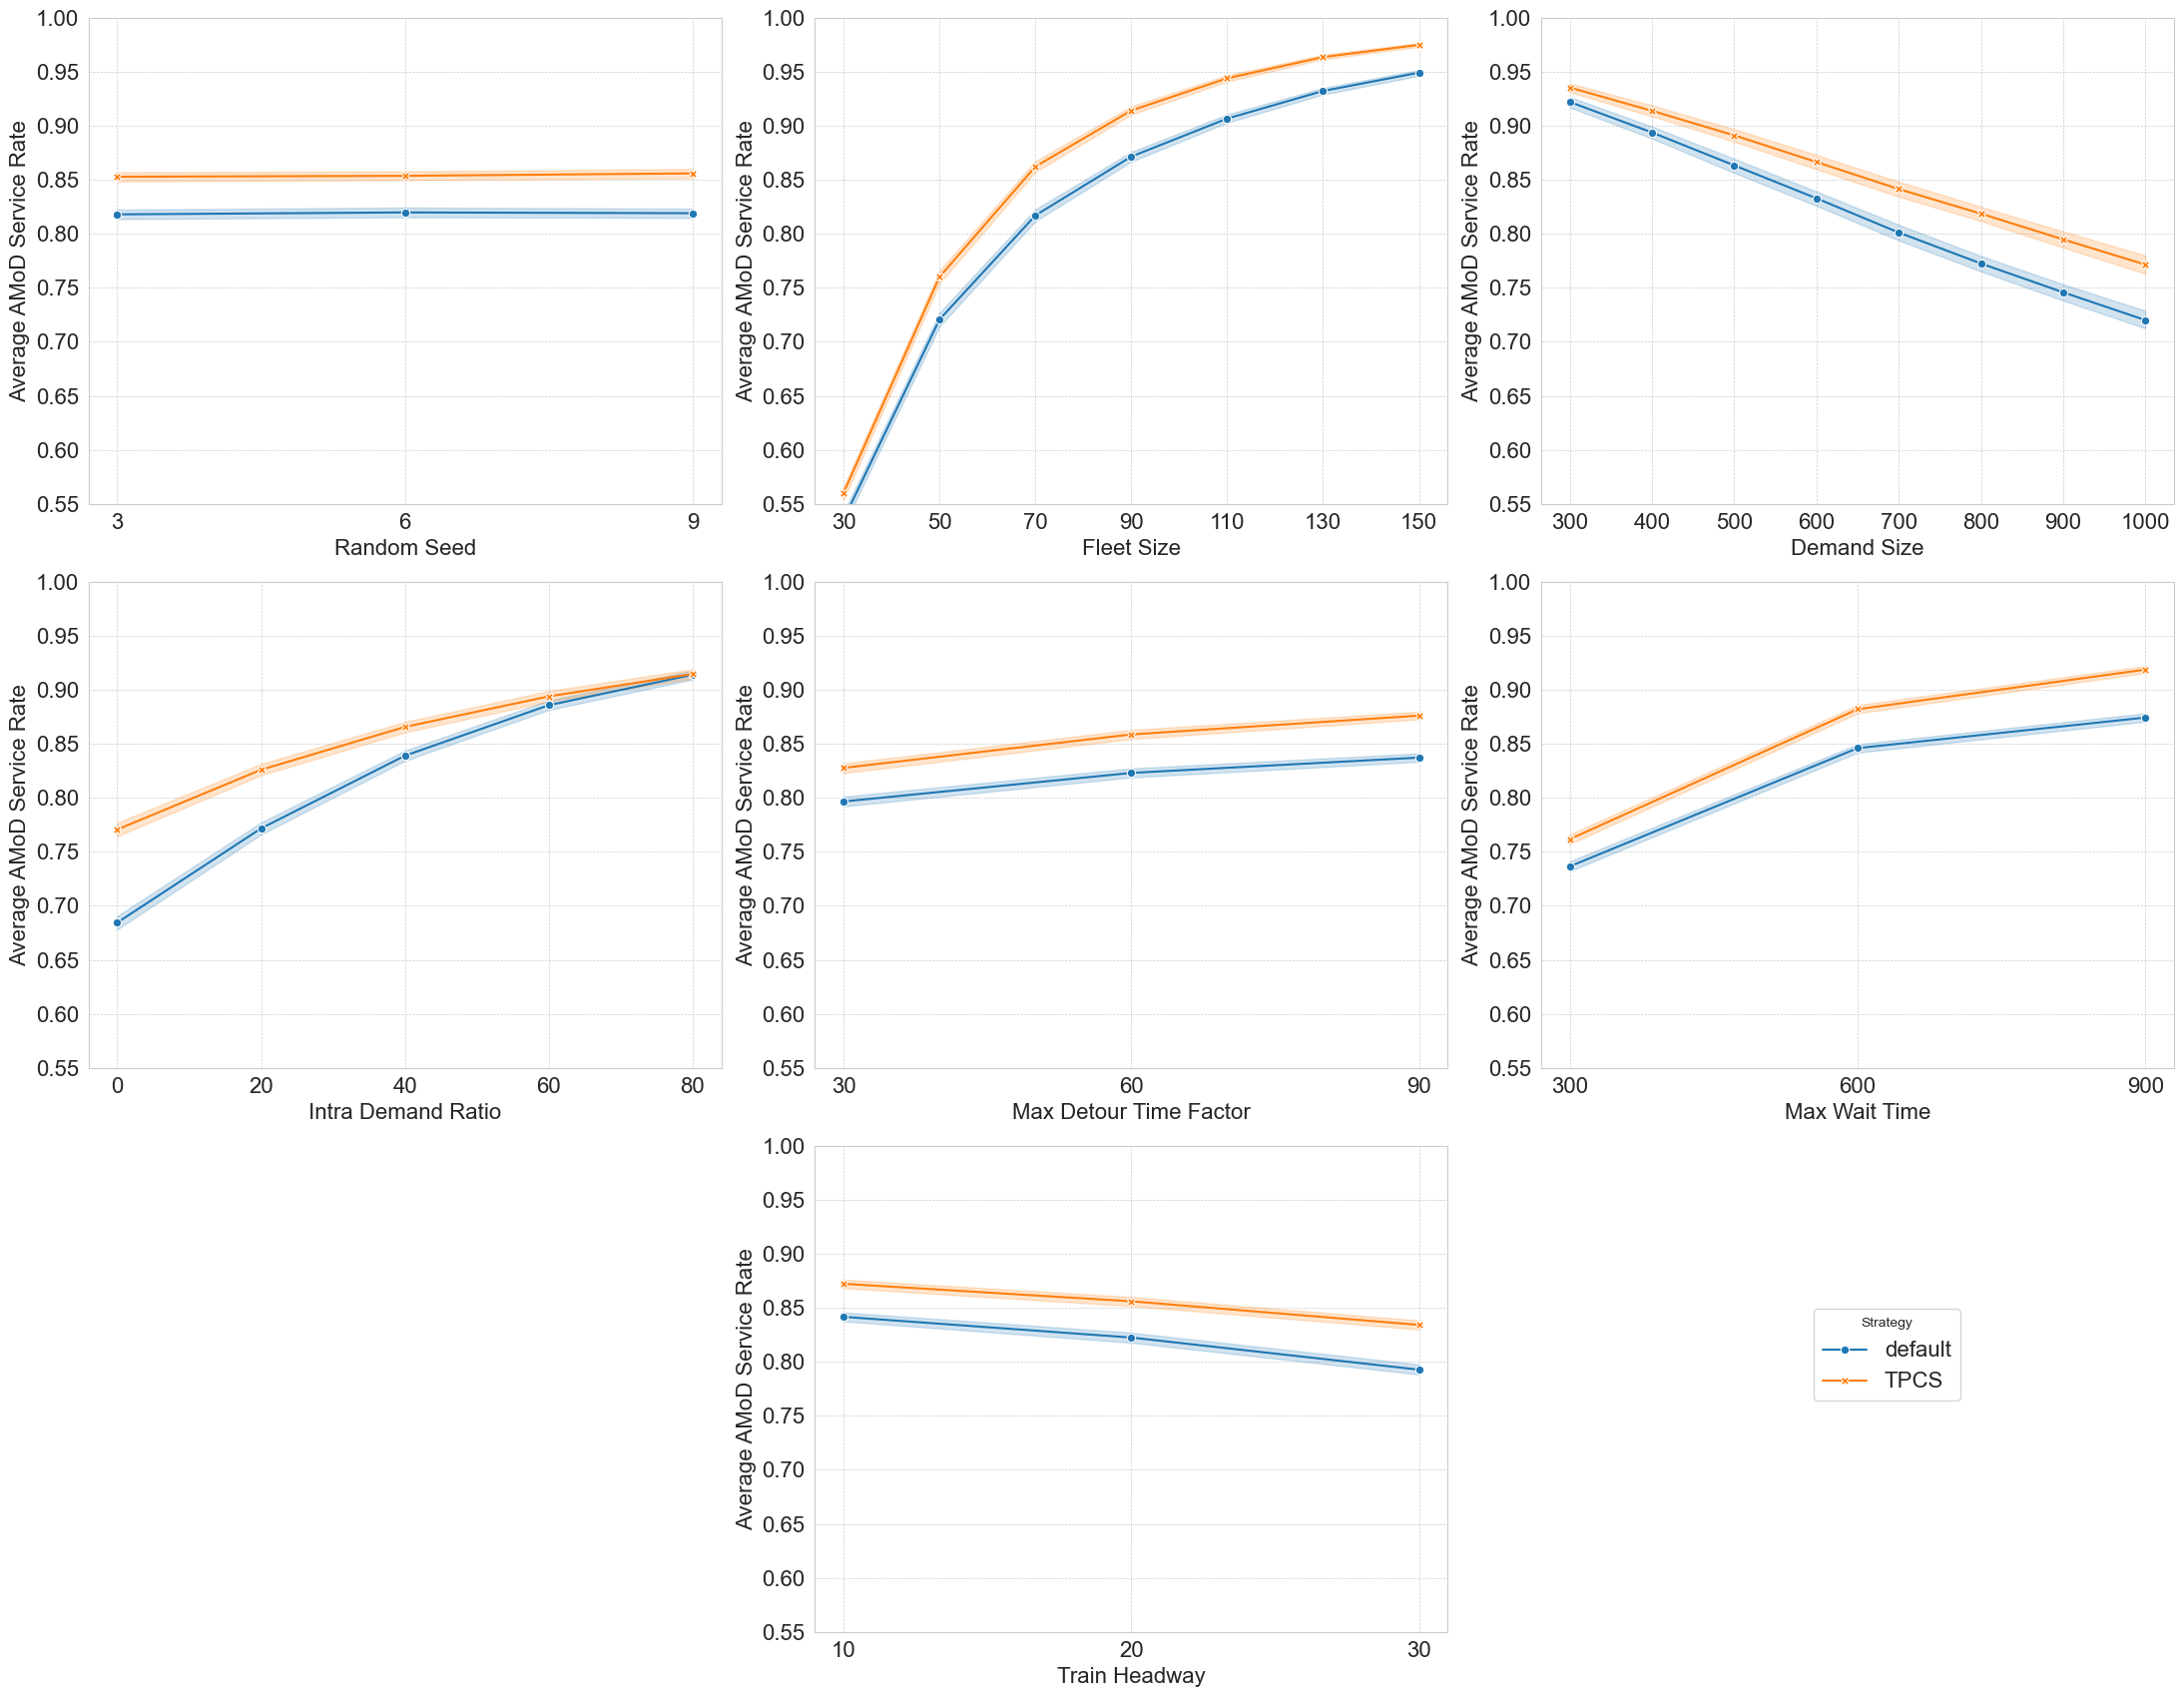

In [15]:
draw_interaction_plots(kpi_column='average_amod_service_rate', y_axis_limit=(0.55, 1.0))

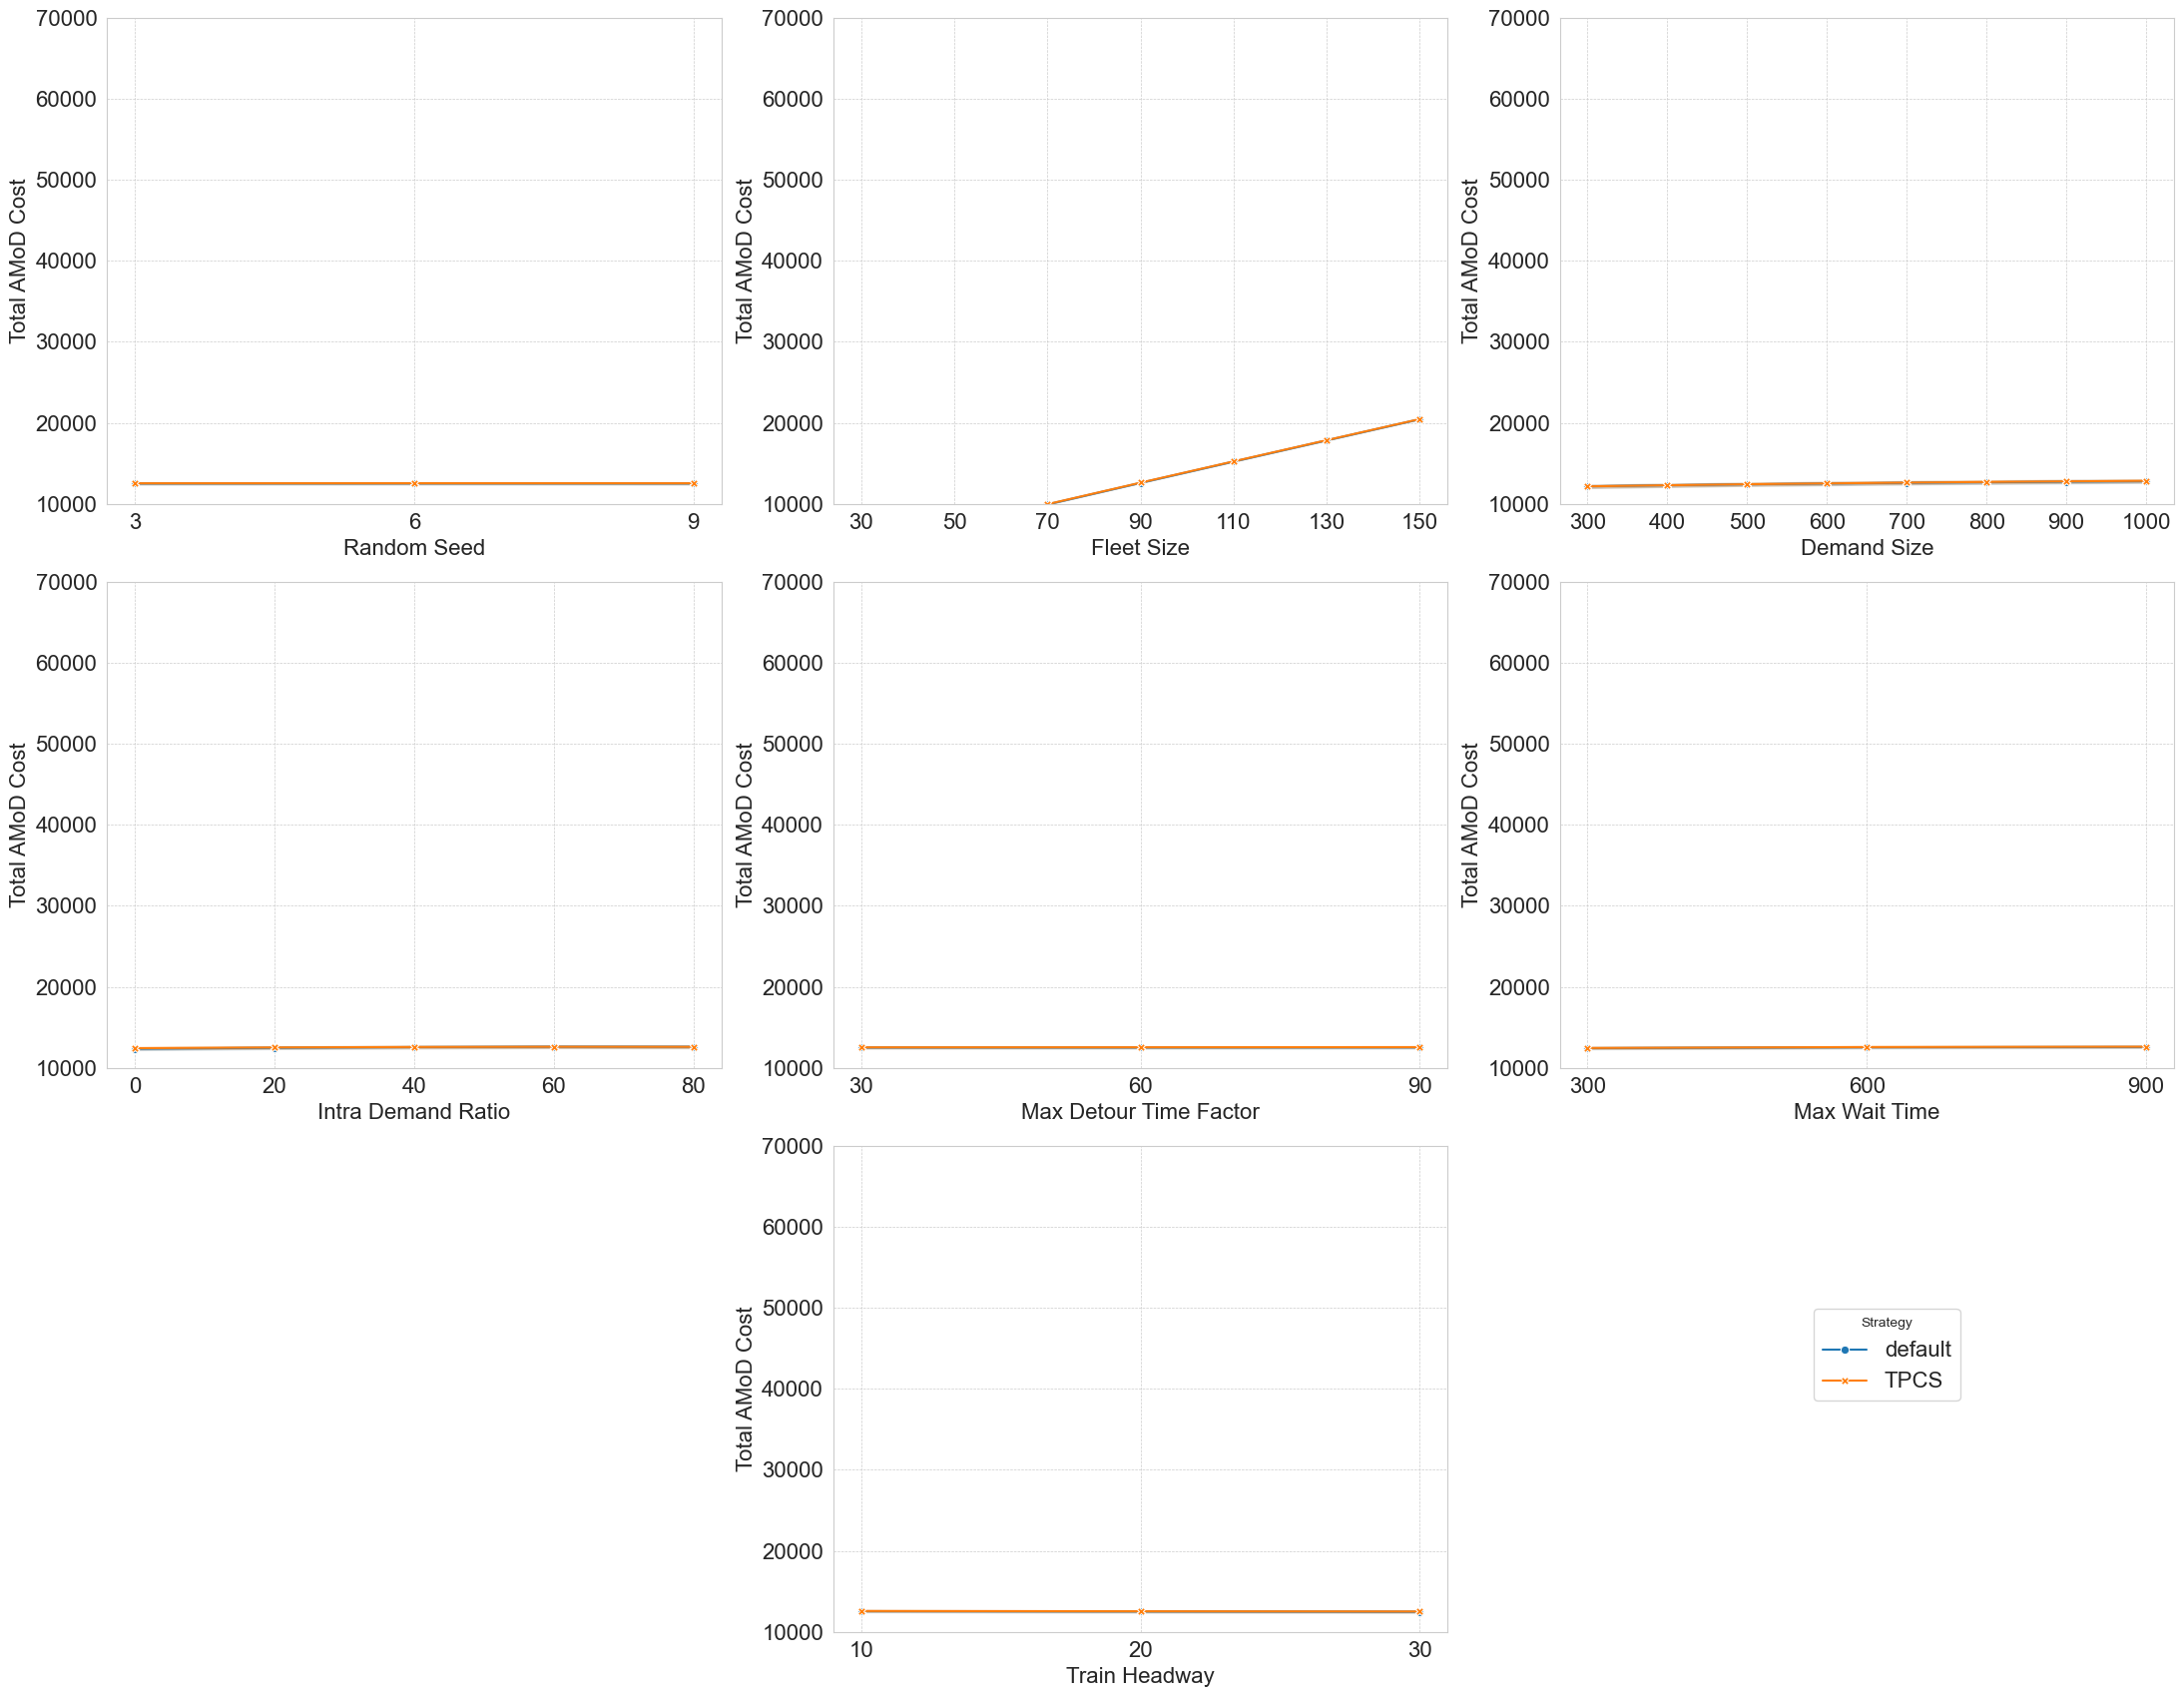

In [16]:
draw_interaction_plots(kpi_column='total_amod_cost', y_axis_limit=(10000, 70000))

# A1: Demand vs Journey Time Saving

In [17]:
a1 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a1 = a1.groupby([
    'demand_size',
    'intra_ratio',
    'broker_type',
]).agg({
    'average_intercity_journey_time': 'mean',
    'average_intracity_journey_time': 'mean',
}).reset_index()

# Rearrange columns
a1 = a1.pivot_table(
    index=['demand_size', 'intra_ratio'],
    columns='broker_type',
    values=['average_intracity_journey_time', 'average_intercity_journey_time']
)

a1.columns = [f"{val[0]}_{val[1]}" for val in a1.columns]

# Calculate the journey time savings
a1['intracity_journey_time_saving'] = a1['average_intracity_journey_time_default'] - a1['average_intracity_journey_time_TPCS']
a1['intercity_journey_time_saving'] = a1['average_intercity_journey_time_default'] - a1['average_intercity_journey_time_TPCS']

a1 = a1.reset_index()

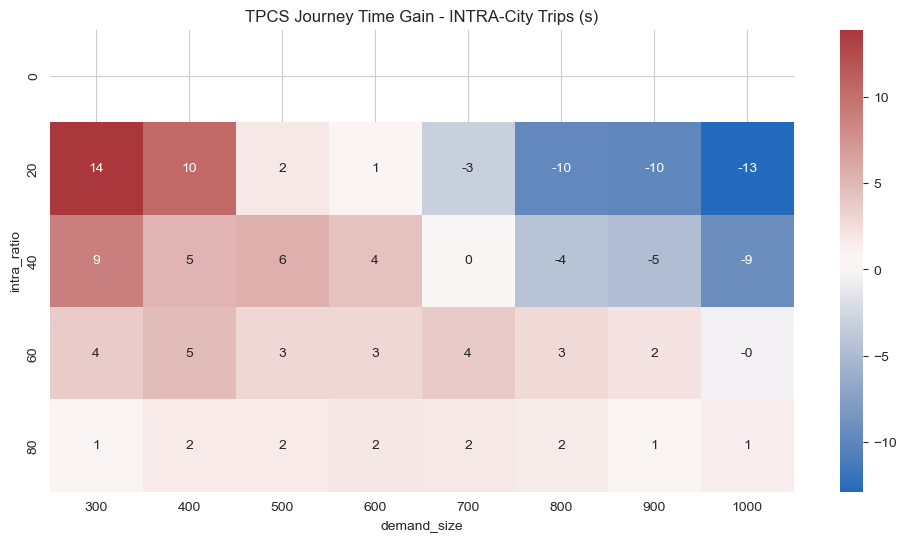

In [18]:
# Visualization of Demand vs Journey Time Saving
heatmap_data_intra = a1.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='intracity_journey_time_saving'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_intra,
    annot=True,
    fmt=".0f",
    cmap="vlag"
)
plt.title("TPCS Journey Time Gain - INTRA-City Trips (s)")
plt.show()

The average strategy gain is: 690.8504369800314


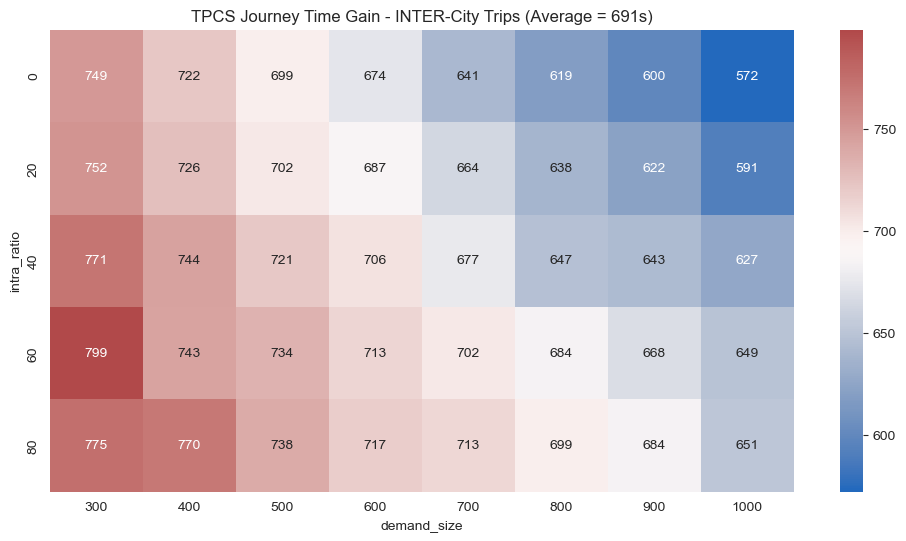

In [19]:
average_gain = a1['intercity_journey_time_saving'].mean()
print(f"The average strategy gain is: {average_gain}")

heatmap_data_inter = a1.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='intercity_journey_time_saving'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_gain
)
plt.title(f"TPCS Journey Time Gain - INTER-City Trips (Average = {average_gain:.0f}s)")
plt.show()

# A1.1: Demand vs Journey Time Saving Extended

In [20]:
a1_1 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a1_1 = a1_1.groupby([
    'demand_size',
    'intra_ratio',
    'broker_type',
]).agg({
    'average_intercity_journey_time_extended': 'mean',
    'average_intracity_journey_time_extended': 'mean',
}).reset_index()

# Rearrange columns
a1_1 = a1_1.pivot_table(
    index=['demand_size', 'intra_ratio'],
    columns='broker_type',
    values=['average_intracity_journey_time_extended', 'average_intercity_journey_time_extended']
)

a1_1.columns = [f"{val[0]}_{val[1]}" for val in a1_1.columns]

# Calculate the journey time savings
a1_1['intracity_journey_time_saving_extended'] = a1_1['average_intracity_journey_time_extended_default'] - a1_1['average_intracity_journey_time_extended_TPCS']
a1_1['intercity_journey_time_saving_extended'] = a1_1['average_intercity_journey_time_extended_default'] - a1_1['average_intercity_journey_time_extended_TPCS']

a1_1 = a1_1.reset_index()

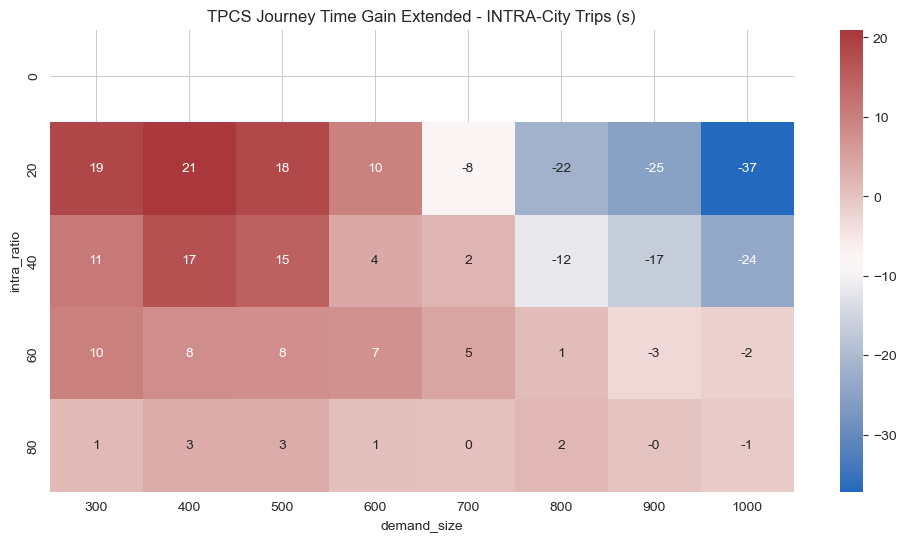

In [21]:
# Visualization of Demand vs Journey Time Saving
heatmap_data_intra = a1_1.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='intracity_journey_time_saving_extended'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_intra,
    annot=True,
    fmt=".0f",
    cmap="vlag"
)
plt.title("TPCS Journey Time Gain Extended - INTRA-City Trips (s)")
plt.show()

The average strategy gain is: 692.0033187041369


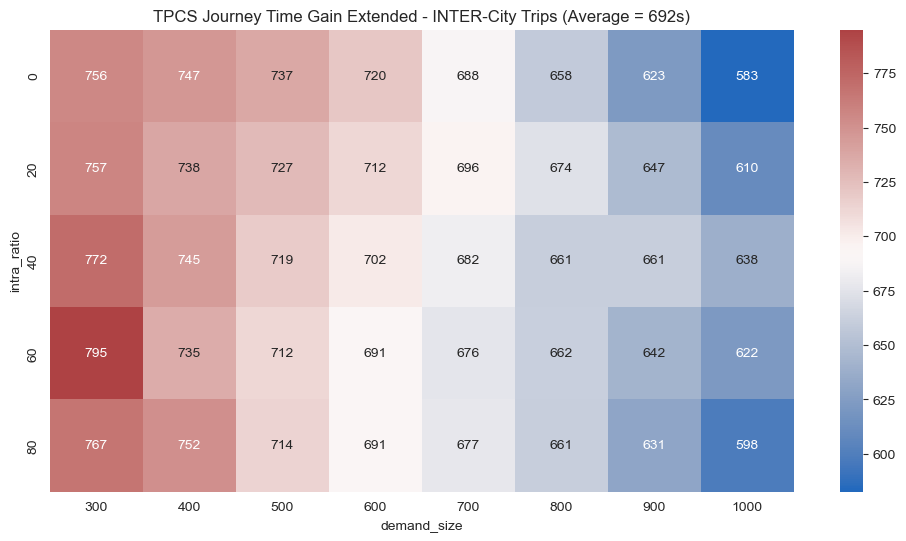

In [22]:
average_gain = a1_1['intercity_journey_time_saving_extended'].mean()
print(f"The average strategy gain is: {average_gain}")

heatmap_data_inter = a1_1.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='intercity_journey_time_saving_extended'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_gain
)
plt.title(f"TPCS Journey Time Gain Extended - INTER-City Trips (Average = {average_gain:.0f}s)")
plt.show()

# A2: Demand vs Service Rate Gain

In [23]:
a2 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a2 = a2.groupby([
    'demand_size',
    'intra_ratio',
    'broker_type',
]).agg({
    'average_amod_service_rate': 'mean',
}).reset_index()

# Rearrange columns
a2 = a2.pivot_table(
    index=['demand_size', 'intra_ratio'],
    columns='broker_type',
    values=['average_amod_service_rate']
)

a2.columns = [f"{val[0]}_{val[1]}" for val in a2.columns]

# Calculate the average service rate gain
a2['average_amod_service_rate_gain'] = a2['average_amod_service_rate_TPCS'] - a2['average_amod_service_rate_default']

a2 = a2.reset_index()

The average strategy gain is: 3.52%


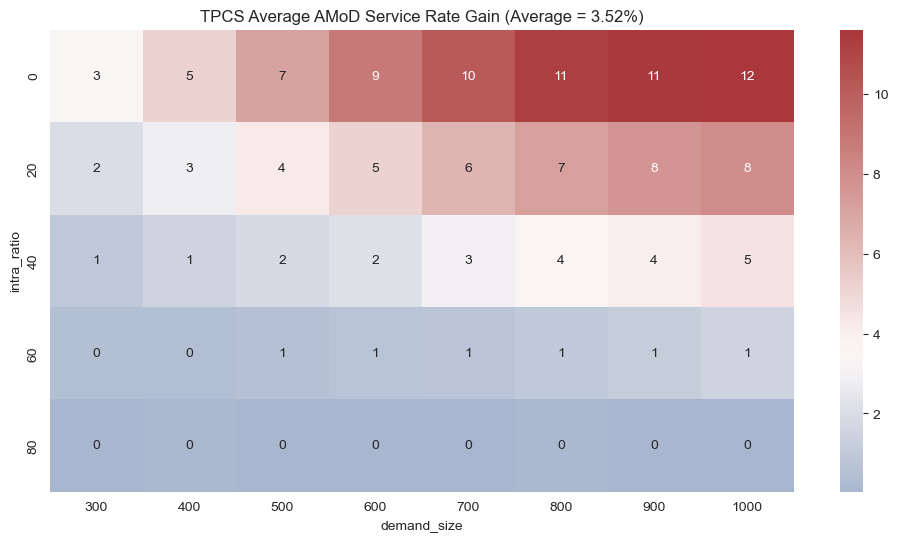

In [24]:
average_gain = a2['average_amod_service_rate_gain'].mean() * 100
print(f"The average strategy gain is: {average_gain:.2f}%")

heatmap_data_inter = a2.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='average_amod_service_rate_gain'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_gain
)
plt.title(f"TPCS Average AMoD Service Rate Gain (Average = {average_gain:.2f}%)")
plt.show()

# A3: Demand vs Service Rate

In [25]:
a3 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a3 = a3.groupby([
    'demand_size',
    'intra_ratio',
    'broker_type',
]).agg({
    'average_amod_service_rate': 'mean',
}).reset_index()

# Rearrange columns
a3 = a3.pivot_table(
    index=['demand_size', 'intra_ratio'],
    columns='broker_type',
    values=['average_amod_service_rate']
)

a3.columns = [f"{val[0]}_{val[1]}" for val in a3.columns]

a3 = a3.reset_index()

The average service rate is: 85.43%


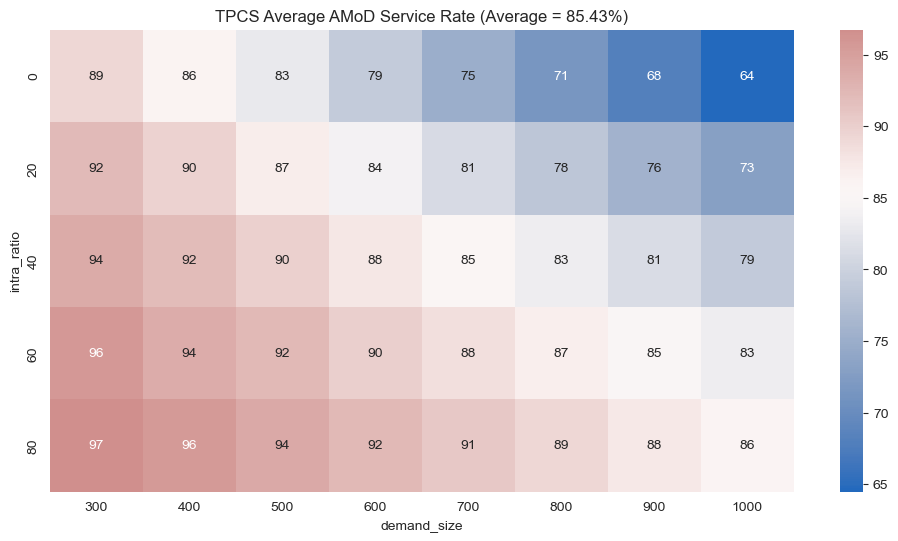

In [26]:
average_service_rate_TPCS = a3['average_amod_service_rate_TPCS'].mean() * 100
print(f"The average service rate is: {average_service_rate_TPCS:.2f}%")

heatmap_data_inter = a3.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='average_amod_service_rate_TPCS'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_TPCS
)
plt.title(f"TPCS Average AMoD Service Rate (Average = {average_service_rate_TPCS:.2f}%)")
plt.show()

The average service rate is: 81.91%


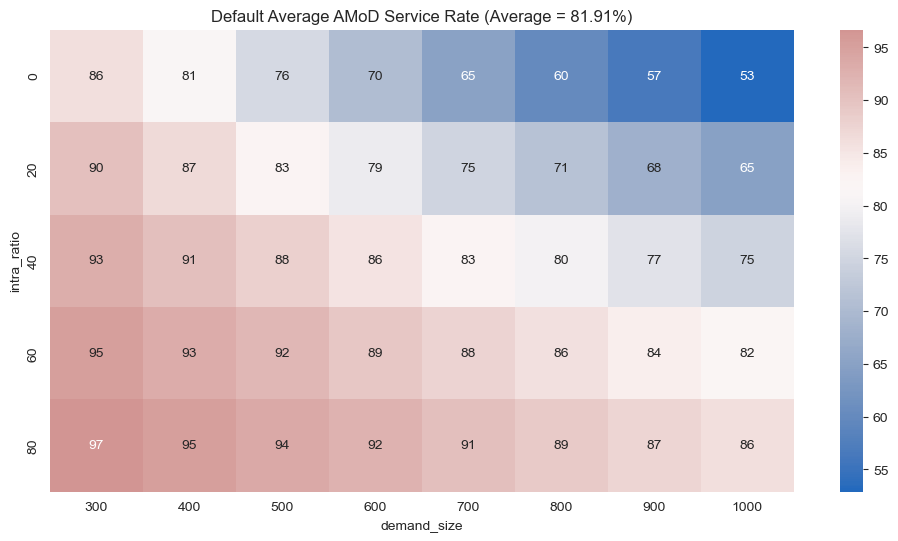

In [27]:
average_service_rate_default = a3['average_amod_service_rate_default'].mean() * 100
print(f"The average service rate is: {average_service_rate_default:.2f}%")

heatmap_data_inter = a3.pivot(
    index='intra_ratio',
    columns='demand_size',
    values='average_amod_service_rate_default'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_default
)
plt.title(f"Default Average AMoD Service Rate (Average = {average_service_rate_default:.2f}%)")
plt.show()

# A4: Fleet Size vs Journey Time Saving

In [28]:
a4 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a4 = a4.groupby([
    'fleet_size',
    'broker_type',
]).agg({
    'average_intercity_journey_time': 'mean',
    'average_intracity_journey_time': 'mean',
}).reset_index()

# Rearrange columns
a4 = a4.pivot_table(
    index=['fleet_size'],
    columns='broker_type',
    values=['average_intercity_journey_time', 'average_intracity_journey_time']
)

a4.columns = [f"{val[0]}_{val[1]}" for val in a4.columns]

# Calculate the journey time savings
a4['intracity_journey_time_saving'] = a4['average_intracity_journey_time_default'] - a4['average_intracity_journey_time_TPCS']
a4['intercity_journey_time_saving'] = a4['average_intercity_journey_time_default'] - a4['average_intercity_journey_time_TPCS']
a4 = a4.reset_index()

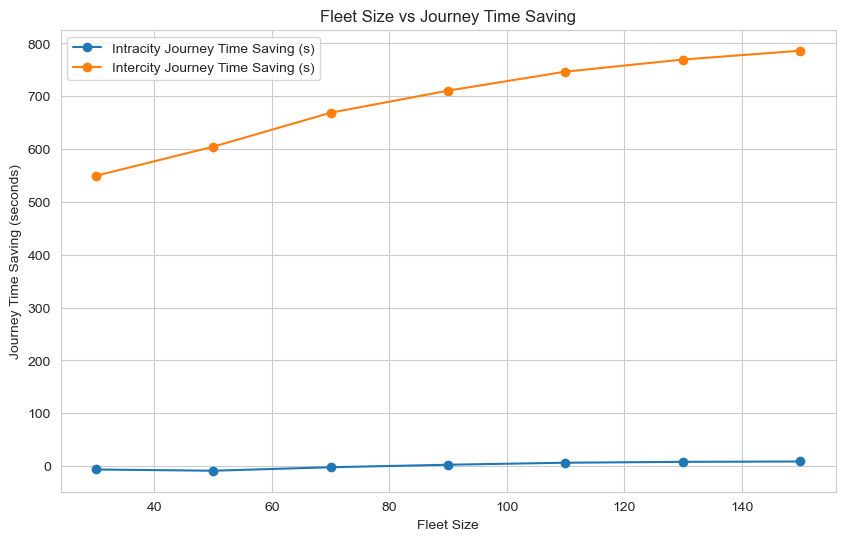

In [29]:
# Visualization of Fleet Size vs Journey Time Saving Using Line Plots
plt.figure(figsize=(10, 6))
plt.plot(
    a4['fleet_size'],
    a4['intracity_journey_time_saving'],
    marker='o',
    label='Intracity Journey Time Saving (s)'
)
plt.plot(
    a4['fleet_size'],
    a4['intercity_journey_time_saving'],
    marker='o',
    label='Intercity Journey Time Saving (s)'
)
plt.xlabel('Fleet Size')
plt.ylabel('Journey Time Saving (seconds)')
plt.title('Fleet Size vs Journey Time Saving')
plt.legend()
plt.grid(True)
plt.show()

# A5: Fleet Size vs Service Rate

In [30]:
a5 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a5 = a5.groupby([
    'fleet_size',
    'broker_type',
]).agg({
    'average_amod_service_rate': 'mean',
}).reset_index()

# Rearrange columns
a5 = a5.pivot_table(
    index=['fleet_size'],
    columns='broker_type',
    values=['average_amod_service_rate']
)

a5.columns = [f"{val[0]}_{val[1]}" for val in a5.columns]

a5 = a5.reset_index()

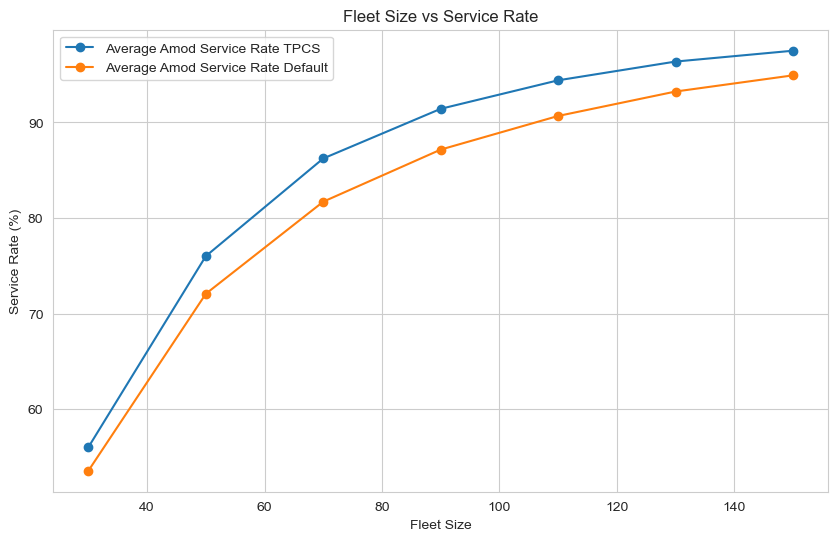

In [31]:
# Visualization of Fleet Size vs Service Rate Using Line Plots
plt.figure(figsize=(10, 6))
plt.plot(
    a5['fleet_size'],
    a5['average_amod_service_rate_TPCS'] * 100,
    marker='o',
    label='Average Amod Service Rate TPCS'
)
plt.plot(
    a5['fleet_size'],
    a5['average_amod_service_rate_default'] * 100,
    marker='o',
    label='Average Amod Service Rate Default'
)
plt.xlabel('Fleet Size')
plt.ylabel('Service Rate (%)')
plt.title('Fleet Size vs Service Rate')
plt.legend()
plt.grid(True)
plt.show()

# A6: Operator Configurations vs Journey Time Saving

In [32]:
a6 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a6 = a6.groupby([
    'op_max_detour_time_factor',
    'op_max_wait_time',
    'broker_type',
]).agg({
    'average_intercity_journey_time': 'mean',
    'average_intracity_journey_time': 'mean',
}).reset_index()

# Rearrange columns
a6 = a6.pivot_table(
    index=['op_max_detour_time_factor', 'op_max_wait_time'],
    columns='broker_type',
    values=['average_intracity_journey_time', 'average_intercity_journey_time']
)

a6.columns = [f"{val[0]}_{val[1]}" for val in a6.columns]

# Calculate the journey time savings
a6['intracity_journey_time_saving'] = a6['average_intracity_journey_time_default'] - a6['average_intracity_journey_time_TPCS']
a6['intercity_journey_time_saving'] = a6['average_intercity_journey_time_default'] - a6['average_intercity_journey_time_TPCS']
a6 = a6.reset_index()

The average strategy gain is: 690.850436980031


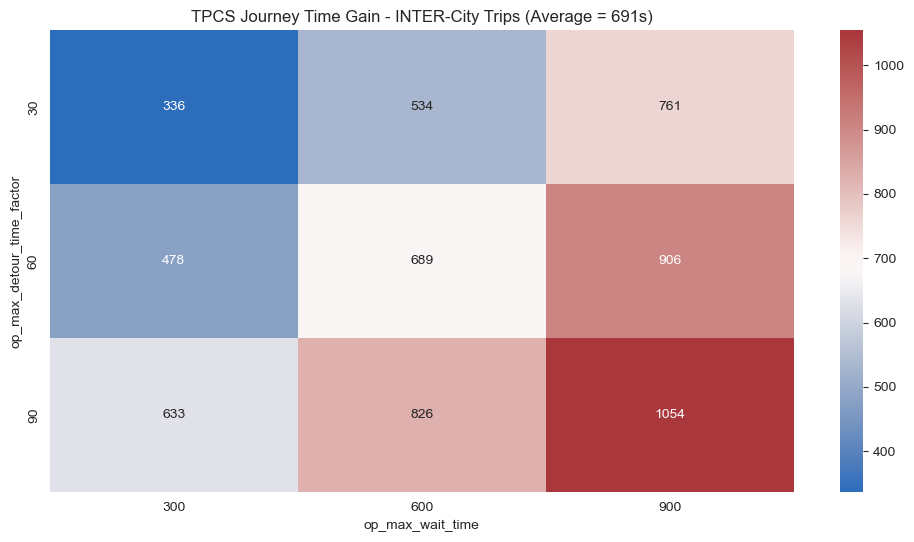

In [33]:
average_gain = a6['intercity_journey_time_saving'].mean()
print(f"The average strategy gain is: {average_gain}")

heatmap_data_inter = a6.pivot(
    index='op_max_detour_time_factor',
    columns='op_max_wait_time',
    values='intercity_journey_time_saving'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_gain
)
plt.title(f"TPCS Journey Time Gain - INTER-City Trips (Average = {average_gain:.0f}s)")
plt.show()

# A7: Operator Configurations vs Service Rate

In [34]:
a7 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a7 = a7.groupby([
    'op_max_detour_time_factor',
    'op_max_wait_time',
    'broker_type',
]).agg({
    'average_amod_service_rate': 'mean',
}).reset_index()

# Rearrange columns
a7 = a7.pivot_table(
    index=['op_max_detour_time_factor', 'op_max_wait_time'],
    columns='broker_type',
    values=['average_amod_service_rate']
)

a7.columns = [f"{val[0]}_{val[1]}" for val in a7.columns]

a7 = a7.reset_index()

The average service rate is: 85.43%


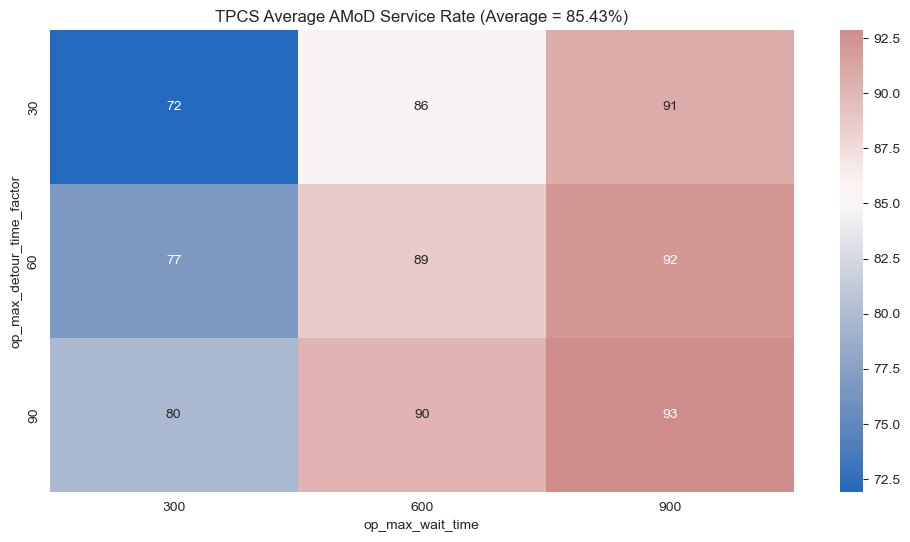

In [35]:
average_service_rate_TPCS = a7['average_amod_service_rate_TPCS'].mean() * 100
print(f"The average service rate is: {average_service_rate_TPCS:.2f}%")

heatmap_data_inter = a7.pivot(
    index='op_max_detour_time_factor',
    columns='op_max_wait_time',
    values='average_amod_service_rate_TPCS'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_TPCS
)
plt.title(f"TPCS Average AMoD Service Rate (Average = {average_service_rate_TPCS:.2f}%)")
plt.show()

The average service rate is: 81.91%


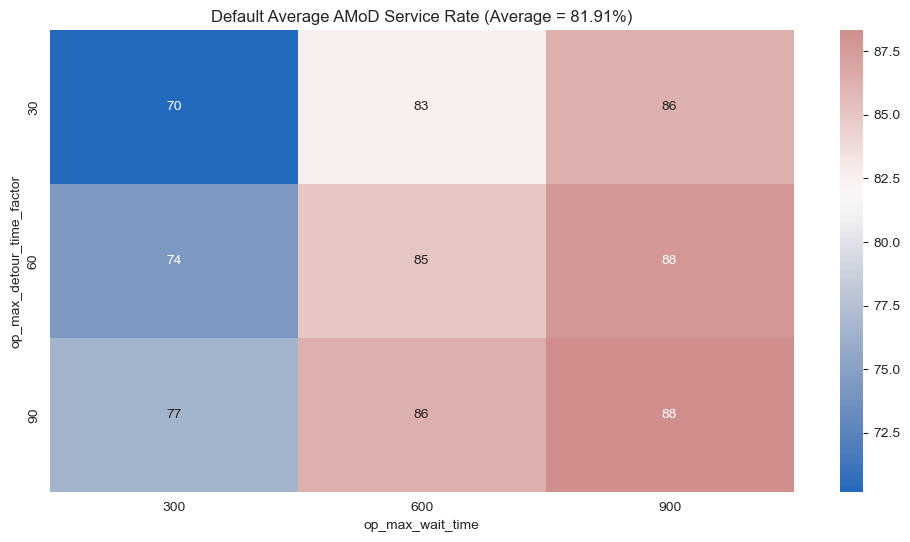

In [36]:
average_service_rate_default = a7['average_amod_service_rate_default'].mean() * 100
print(f"The average service rate is: {average_service_rate_default:.2f}%")

heatmap_data_inter = a7.pivot(
    index='op_max_detour_time_factor',
    columns='op_max_wait_time',
    values='average_amod_service_rate_default'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_default
)
plt.title(f"Default Average AMoD Service Rate (Average = {average_service_rate_default:.2f}%)")
plt.show()

# A8 Fleet Size & Demand Size vs Fleet Utilization Rate

In [37]:
a8 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a8 = a8.groupby([
    'demand_size',
    'fleet_size',
    'broker_type',
]).agg({
    'fleet_utilization_rate': 'mean',
}).reset_index()

# Rearrange columns
a8 = a8.pivot_table(
    index=['demand_size', 'fleet_size'],
    columns='broker_type',
    values=['fleet_utilization_rate']
)

a8.columns = [f"{val[0]}_{val[1]}" for val in a8.columns]
    
a8 = a8.reset_index()

The average fleet utilization rate is: 80.15%


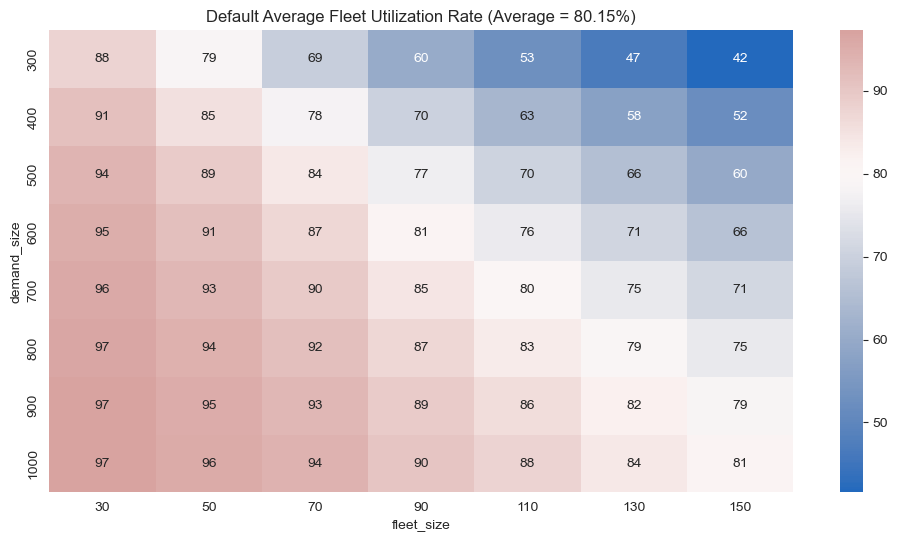

In [38]:
average_fleet_utilization_rate_default = a8['fleet_utilization_rate_default'].mean()
print(f"The average fleet utilization rate is: {average_fleet_utilization_rate_default:.2f}%")

heatmap_data_inter = a8.pivot(
    index='demand_size',
    columns='fleet_size',
    values='fleet_utilization_rate_default'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_fleet_utilization_rate_default
)
plt.title(f"Default Average Fleet Utilization Rate (Average = {average_fleet_utilization_rate_default:.2f}%)")
plt.show()

The average fleet utilization rate is: 78.35%


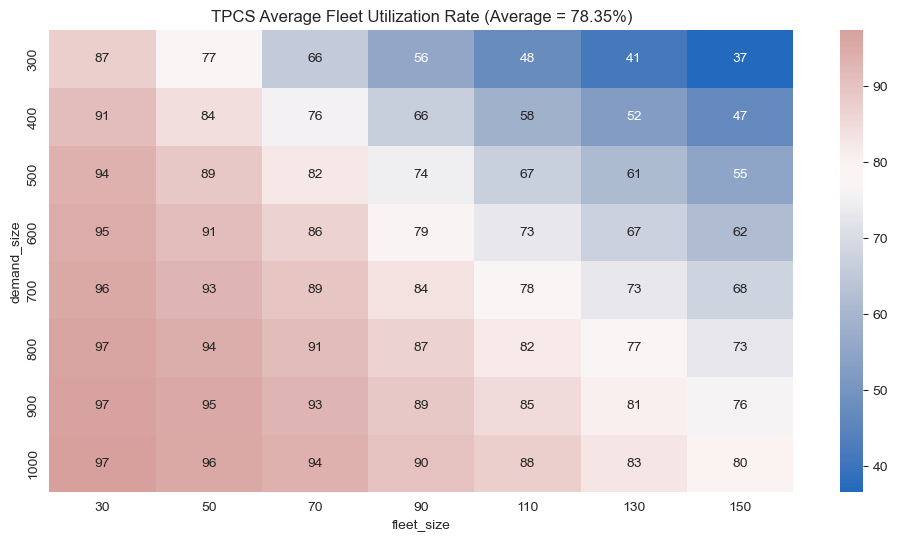

In [39]:
average_fleet_utilization_rate_TPCS = a8['fleet_utilization_rate_TPCS'].mean()
print(f"The average fleet utilization rate is: {average_fleet_utilization_rate_TPCS:.2f}%")

heatmap_data_inter = a8.pivot(
    index='demand_size',
    columns='fleet_size',
    values='fleet_utilization_rate_TPCS'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_fleet_utilization_rate_TPCS
)
plt.title(f"TPCS Average Fleet Utilization Rate (Average = {average_fleet_utilization_rate_TPCS:.2f}%)")
plt.show()

# A9 Fleet Size & Demand Size vs Service Rate

In [40]:
a9 = amod_scenarios_results.copy()

# Aggregate irrelevant columns
a9 = a9.groupby([
    'fleet_size',
    'demand_size',
    'broker_type',
]).agg({
    'average_amod_service_rate': 'mean',
}).reset_index()

# Rearrange columns
a9 = a9.pivot_table(
    index=['fleet_size', 'demand_size'],
    columns='broker_type',
    values=['average_amod_service_rate']
)

a9.columns = [f"{val[0]}_{val[1]}" for val in a9.columns]

a9 = a9.reset_index()

The average service rate is: 85.43%


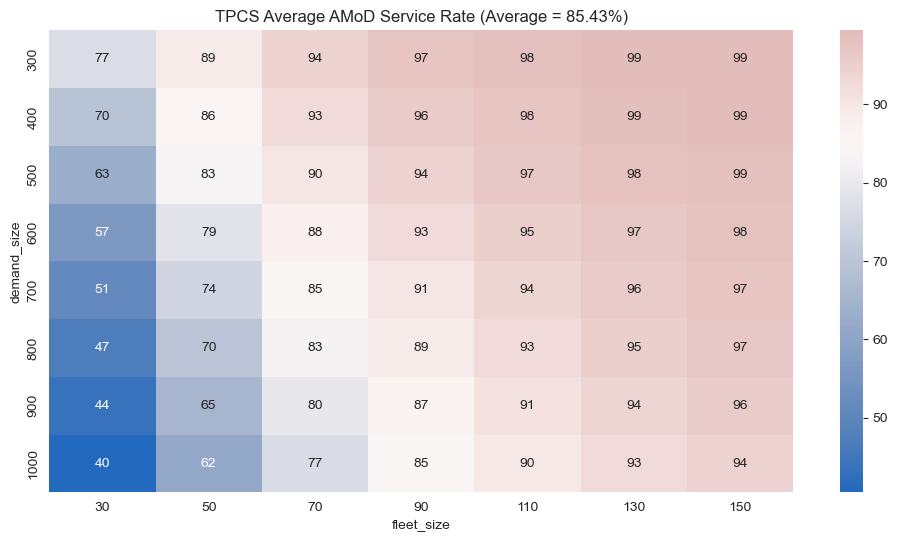

In [41]:
average_service_rate_TPCS = a9['average_amod_service_rate_TPCS'].mean() * 100
print(f"The average service rate is: {average_service_rate_TPCS:.2f}%")

heatmap_data_inter = a9.pivot(
    index='demand_size',
    columns='fleet_size',
    values='average_amod_service_rate_TPCS'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_TPCS
)
plt.title(f"TPCS Average AMoD Service Rate (Average = {average_service_rate_TPCS:.2f}%)")
plt.show()

The average service rate is: 81.91%


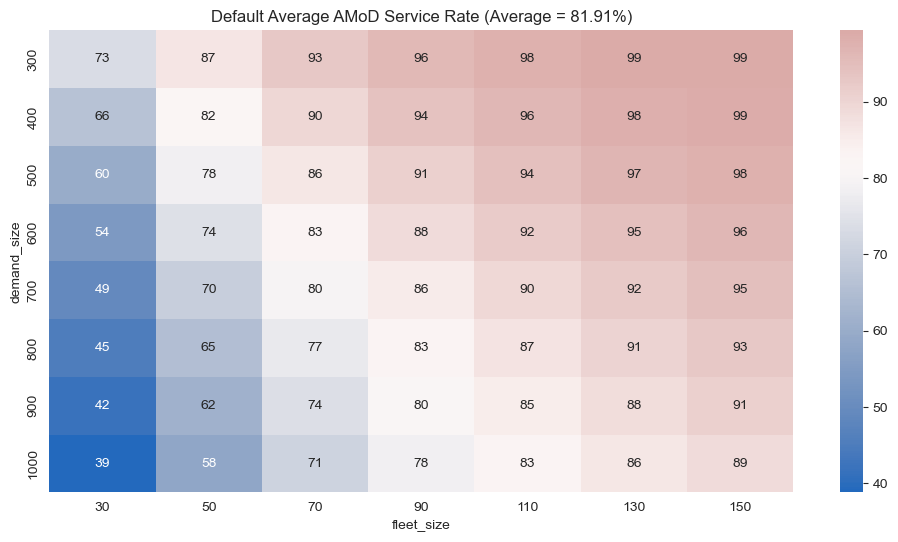

In [42]:
average_service_rate_default = a9['average_amod_service_rate_default'].mean() * 100
print(f"The average service rate is: {average_service_rate_default:.2f}%")

heatmap_data_inter = a9.pivot(
    index='demand_size',
    columns='fleet_size',
    values='average_amod_service_rate_default'
)

# Convert to percentage
heatmap_data_inter = heatmap_data_inter * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_inter,
    annot=True,
    fmt=".0f",
    cmap="vlag",
    center=average_service_rate_default
)
plt.title(f"Default Average AMoD Service Rate (Average = {average_service_rate_default:.2f}%)")
plt.show()